# TPE + gradient weights — cleaned in the style of `fin_3`

Цель ноутбука — аккуратно проверить модификацию TPE с дополнительным множителем \(w(x)\), зависящим от градиента benchmark-функции.

Структура приведена к той же логике, что и в `fin_3_raw_vs_norm_METRICS_VISIBLE_FIXED_2.ipynb`:

- отдельно заданы raw clean functions;
- normalized objective строится через фиксированные константы `NORM_CONST`;
- шум добавляется к той шкале, которую реально видит оптимизатор;
- итоговое качество всегда считается по raw clean objective;
- для сравнения сохраняются `observed_loss`, `raw_clean_curve`, `x_distance_curve`, шаги до raw-порога и success rate;
- random, no_w, gradient-weighted TPE и Optuna запускаются в одной схеме.

In [ ]:
# ============================================================
# ЯЧЕЙКА 1: Установка зависимостей
# ============================================================
!pip uninstall -y ConfigSpace
!pip install -U "ConfigSpace==1.2.0"
!pip -q install parzen-estimator numpy matplotlib optuna

Found existing installation: ConfigSpace 1.2.0
Uninstalling ConfigSpace-1.2.0:
  Successfully uninstalled ConfigSpace-1.2.0
  Using cached configspace-1.2.0-py3-none-any.whl


In [ ]:
# ============================================================
# 1. Imports + repo path
# Блок повторяет рабочую схему imports.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
import sys
import pandas as pd
import math

import ConfigSpace as CS
import ConfigSpace.hyperparameters as CSH

try:
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except Exception as e:
    HAS_OPTUNA = False
    print("Optuna не импортировалась:", repr(e))

# ------------------------------------------------------------
# ConfigSpace q-patch
# ------------------------------------------------------------

def _q_prop(self):
    return getattr(self, "_q", None)

_NEED_Q = [
    "UniformFloatHyperparameter",
    "UniformIntegerHyperparameter",
    "NormalFloatHyperparameter",
    "NormalIntegerHyperparameter",
]

for name in _NEED_Q:
    cls = getattr(CSH, name, None)
    if cls is not None and not hasattr(cls, "q"):
        setattr(cls, "q", property(_q_prop))

# ------------------------------------------------------------
# Google Drive
# ------------------------------------------------------------

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount skipped:", repr(e))

# ------------------------------------------------------------
# Repo path: добавляем только корень, где лежит папка tpe.
# ------------------------------------------------------------

TPE_ROOT = Path("drive/MyDrive/content")

if not (TPE_ROOT / "tpe").exists():
    alt = Path("/content/drive/MyDrive/content")
    if (alt / "tpe").exists():
        TPE_ROOT = alt

if not (TPE_ROOT / "tpe").exists():
    raise FileNotFoundError(
        f"Не найдена папка repo: {TPE_ROOT / 'tpe'}"
    )

if str(TPE_ROOT) not in sys.path:
    sys.path.append(str(TPE_ROOT))

for key in list(sys.modules.keys()):
    if key == "tpe" or key.startswith("tpe."):
        del sys.modules[key]

(TPE_ROOT / "tpe" / "__init__.py").touch(exist_ok=True)

from tpe.optimizer.tpe_optimizer import TPEOptimizer
from tpe.optimizer.random_search import RandomSearch

print("TPE_ROOT =", TPE_ROOT)
print("Repo imports OK")
print("HAS_OPTUNA =", HAS_OPTUNA)

Mounted at /content/drive
TPE_ROOT = drive/MyDrive/content
Repo imports OK
HAS_OPTUNA = True


# 2. Raw clean functions

In [ ]:
def sphere_raw(x):
    x = np.asarray(x, dtype=float)
    return float(np.sum(x ** 2))


def rosenbrock_raw(x):
    x = np.asarray(x, dtype=float)
    return float(
        np.sum(
            100.0 * (x[1:] - x[:-1] ** 2) ** 2
            + (1.0 - x[:-1]) ** 2
        )
    )


def rastrigin_raw(x):
    x = np.asarray(x, dtype=float)
    d = len(x)
    return float(
        10.0 * d + np.sum(x ** 2 - 10.0 * np.cos(2.0 * np.pi * x))
    )


def ackley_raw(x):
    x = np.asarray(x, dtype=float)
    d = len(x)
    a = 20.0
    b = 0.2
    c = 2.0 * np.pi
    s1 = np.sum(x ** 2)
    s2 = np.sum(np.cos(c * x))
    return float(
        -a * np.exp(-b * np.sqrt(s1 / d))
        - np.exp(s2 / d)
        + a
        + np.e
    )


RAW_CLEAN_MAP = {
    "Sphere(2D)": sphere_raw,
    "Rosenbrock(2D)": rosenbrock_raw,
    "Rastrigin(2D)": rastrigin_raw,
    "Ackley(2D)": ackley_raw,
}

TRUE_MINIMA = {
    "Sphere(2D)": np.array([0.0, 0.0]),
    "Rosenbrock(2D)": np.array([1.0, 1.0]),
    "Rastrigin(2D)": np.array([0.0, 0.0]),
    "Ackley(2D)": np.array([0.0, 0.0]),
}

# 3. ConfigSpace

In [ ]:
def make_cs(bounds, seed=0):
    cs = CS.ConfigurationSpace(seed=seed)
    hps = [
        CSH.UniformFloatHyperparameter(name, lower=lo, upper=hi)
        for name, lo, hi in bounds
    ]
    cs.add_hyperparameters(hps)
    return cs


BOUNDS_MAP = {
    "Sphere(2D)":     [(-5.0, 5.0), (-5.0, 5.0)],
    "Rosenbrock(2D)": [(-2.0, 2.0), (-1.0, 3.0)],
    "Rastrigin(2D)":  [(-5.12, 5.12), (-5.12, 5.12)],
    "Ackley(2D)":     [(-5.0, 5.0), (-5.0, 5.0)],
}

CS_MAP = {
    fn_name: make_cs(
        [("x0", bounds[0][0], bounds[0][1]), ("x1", bounds[1][0], bounds[1][1])],
        seed=0,
    )
    for fn_name, bounds in BOUNDS_MAP.items()
}

# 4. Raw analytical gradients

Градиенты заданы для raw functions. Для normalized objective используется правило цепочки:

\[
\nabla f_{norm}(x)=\frac{\nabla f_{raw}(x)}{f_{max}-f_{min}}.
\]

In [ ]:
def sphere_raw_gradient(x):
    x = np.asarray(x, dtype=float)
    return 2.0 * x


def rosenbrock_raw_gradient(x):
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x, dtype=float)
    grad[:-1] += -400.0 * x[:-1] * (x[1:] - x[:-1] ** 2) - 2.0 * (1.0 - x[:-1])
    grad[1:] += 200.0 * (x[1:] - x[:-1] ** 2)
    return grad


def rastrigin_raw_gradient(x):
    x = np.asarray(x, dtype=float)
    return 2.0 * x + 20.0 * np.pi * np.sin(2.0 * np.pi * x)


def ackley_raw_gradient(x):
    x = np.asarray(x, dtype=float)
    d = len(x)
    a = 20.0
    b = 0.2
    c = 2.0 * np.pi

    s1 = np.sum(x ** 2)
    s2 = np.sum(np.cos(c * x))

    if s1 <= 1e-14:
        term1_grad = np.zeros_like(x, dtype=float)
    else:
        sqrt_s1_d = np.sqrt(s1 / d)
        exp1 = np.exp(-b * sqrt_s1_d)
        term1_grad = a * b * exp1 * x / (d * sqrt_s1_d)

    exp2 = np.exp(s2 / d)
    term2_grad = exp2 * (c / d) * np.sin(c * x)
    return term1_grad + term2_grad


RAW_GRADIENT_MAP = {
    "Sphere(2D)": sphere_raw_gradient,
    "Rosenbrock(2D)": rosenbrock_raw_gradient,
    "Rastrigin(2D)": rastrigin_raw_gradient,
    "Ackley(2D)": ackley_raw_gradient,
}

print("Raw gradients are defined:", list(RAW_GRADIENT_MAP.keys()))

Raw gradients are defined: ['Sphere(2D)', 'Rosenbrock(2D)', 'Rastrigin(2D)', 'Ackley(2D)']


# 5. Normalization

In [ ]:
def estimate_fmax(fn, bounds, n_samples=50_000, seed=123):
    rng = np.random.default_rng(seed)
    low = np.array([b[0] for b in bounds], dtype=float)
    high = np.array([b[1] for b in bounds], dtype=float)
    X = rng.uniform(low, high, size=(n_samples, len(bounds)))
    vals = np.array([fn(x) for x in X], dtype=float)
    return float(vals.max())


NORM_CONST = {}

for fn_name, fn in RAW_CLEAN_MAP.items():
    f_min = 0.0
    f_max = estimate_fmax(fn, BOUNDS_MAP[fn_name], n_samples=50_000, seed=123)
    NORM_CONST[fn_name] = {"min": f_min, "max": f_max}

NORM_CONST

{'Sphere(2D)': {'min': 0.0, 'max': 49.91545822682126},
 'Rosenbrock(2D)': {'min': 0.0, 'max': 2454.370440570294},
 'Rastrigin(2D)': {'min': 0.0, 'max': 80.7004898714919},
 'Ackley(2D)': {'min': 0.0, 'max': 14.302175010131323}}

In [ ]:
def make_norm_clean_fn(fn_name):
    raw_fn = RAW_CLEAN_MAP[fn_name]
    f_min = NORM_CONST[fn_name]["min"]
    f_max = NORM_CONST[fn_name]["max"]
    denom = max(f_max - f_min, 1e-12)

    def norm_fn(x):
        return float((raw_fn(x) - f_min) / denom)

    return norm_fn


NORM_CLEAN_MAP = {
    fn_name: make_norm_clean_fn(fn_name)
    for fn_name in RAW_CLEAN_MAP.keys()
}

In [ ]:
def make_norm_gradient_fn(fn_name):
    raw_grad_fn = RAW_GRADIENT_MAP[fn_name]
    f_min = NORM_CONST[fn_name]["min"]
    f_max = NORM_CONST[fn_name]["max"]
    denom = max(f_max - f_min, 1e-12)

    def norm_grad_fn(x):
        return np.asarray(raw_grad_fn(x), dtype=float) / denom

    return norm_grad_fn


NORM_GRADIENT_MAP = {fn_name: make_norm_gradient_fn(fn_name) for fn_name in RAW_GRADIENT_MAP.keys()}
GRADIENT_MAP_BY_SCALE = {"raw": RAW_GRADIENT_MAP, "norm": NORM_GRADIENT_MAP}

print("Normalized gradients are defined.")

Normalized gradients are defined.


# 6. Noise settings

In [ ]:
NOISE_SIGMA_RAW = {
    "Sphere(2D)":     0.005,
    "Rosenbrock(2D)": 0.05,
    "Rastrigin(2D)":  0.25,
    "Ackley(2D)":     0.05,
}

# Для normalized objective переводим raw sigma в normalized scale
NOISE_SIGMA_NORM = {
    fn_name: NOISE_SIGMA_RAW[fn_name] / max(NORM_CONST[fn_name]["max"] - NORM_CONST[fn_name]["min"], 1e-12)
    for fn_name in RAW_CLEAN_MAP.keys()
}

NOISE_SIGMA_NORM

{'Sphere(2D)': 0.00010016936992302981,
 'Rosenbrock(2D)': 2.037182292188219e-05,
 'Rastrigin(2D)': 0.0030978746275035257,
 'Ackley(2D)': 0.00349597176405555}

In [ ]:
def make_objective_fn(fn_name, scale_type, data_type, seed):
    if scale_type == "raw":
        clean_obj = RAW_CLEAN_MAP[fn_name]
        sigma = NOISE_SIGMA_RAW[fn_name]
    elif scale_type == "norm":
        clean_obj = NORM_CLEAN_MAP[fn_name]
        sigma = NOISE_SIGMA_NORM[fn_name]
    else:
        raise ValueError(scale_type)

    if data_type == "clean":
        return clean_obj

    if data_type == "noisy_y":
        rng = np.random.default_rng(
            100_000
            + 997 * seed
            + abs(hash((fn_name, scale_type, data_type))) % 100_000
        )

        def noisy_obj(x):
            return float(clean_obj(x) + rng.normal(0.0, sigma))

        return noisy_obj

    raise ValueError(data_type)

# 7. Gradient weight functions

Используются четыре варианта множителя \(w(x)\). Все они ограничены диапазоном `[0.8, 1.2]`, чтобы вес был мягкой модификацией TPE, а не заменял базовое отношение `l(x) / g(x)`.

In [ ]:
def _as_2d_points(x_points):
    """
    Приводит вход weight_fn к массиву точек формы (n_points, 2).

    Если TPE передает только одномерный массив, полноценный 2D-градиент восстановить нельзя.
    Для совместимости используется проекция x1=0.0. Для статьи нужно отдельно проверить,
    как именно ваш TPEOptimizer вызывает weight_fn.
    """
    arr = np.asarray(x_points, dtype=float)
    if arr.size == 0:
        return np.empty((0, 2), dtype=float)
    if arr.ndim == 1:
        return np.column_stack([arr, np.zeros_like(arr)])
    if arr.ndim == 2 and arr.shape[1] >= 2:
        return arr[:, :2]
    if arr.ndim == 2 and arr.shape[1] == 1:
        col = arr[:, 0]
        return np.column_stack([col, np.zeros_like(col)])
    raise ValueError(f"Unsupported x_points shape for weight_fn: {arr.shape}")


def _normalize_to_minus_one_one(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values
    v_min = float(np.min(values))
    v_max = float(np.max(values))
    if (v_max - v_min) <= 1e-12:
        return np.zeros_like(values, dtype=float)
    return 2.0 * (values - v_min) / (v_max - v_min) - 1.0


def make_gradient_weight_function(fn_name, scale_type="norm", weight_type="smooth"):
    if scale_type not in GRADIENT_MAP_BY_SCALE:
        raise ValueError(scale_type)
    grad_fn = GRADIENT_MAP_BY_SCALE[scale_type][fn_name]

    def weight_fn(x_points):
        points = _as_2d_points(x_points)
        if len(points) == 0:
            return np.array([], dtype=float)

        gradients = np.array([grad_fn(point) for point in points], dtype=float)
        grad_norms = np.linalg.norm(gradients, axis=1)
        z0 = _normalize_to_minus_one_one(grad_norms)

        if weight_type == "smooth":
            z = np.tanh(z0)
        elif weight_type == "smooth_inv":
            z = -np.tanh(z0)
        elif weight_type == "sign_like":
            z = 2.0 / (1.0 + np.exp(-np.clip(5.0 * z0, -500.0, 500.0))) - 1.0
        elif weight_type == "sign_like_inv":
            z = -(2.0 / (1.0 + np.exp(-np.clip(5.0 * z0, -500.0, 500.0))) - 1.0)
        else:
            raise ValueError(weight_type)

        return np.clip(1.0 + 0.2 * z, 0.8, 1.2)

    return weight_fn


def create_gradient_weights(fn_name, scale_type):
    return {
        "grad_smooth": make_gradient_weight_function(fn_name, scale_type, "smooth"),
        "grad_smooth_inv": make_gradient_weight_function(fn_name, scale_type, "smooth_inv"),
        "grad_sign_like": make_gradient_weight_function(fn_name, scale_type, "sign_like"),
        "grad_sign_like_inv": make_gradient_weight_function(fn_name, scale_type, "sign_like_inv"),
    }


print("Gradient weight factory is ready.")

Gradient weight factory is ready.


# 8. Experiment settings

In [ ]:
SEEDS = tuple(range(30))

N_INIT = 10
MAX_EVALS = 100

BASE_KWARGS = dict(
    n_ei_candidates=24,
    min_bandwidth_factor=1e-2,
    top=0.2,
)

# Thresholds считаются только по RAW clean objective.
# Они отвечают на вопрос: за сколько итераций алгоритм достиг приемлемого raw-качества.
THRESHOLDS_RAW = {
    "Sphere(2D)":     1e-3,
    "Rosenbrock(2D)": 5e-2,
    "Rastrigin(2D)":  1.0,
    "Ackley(2D)":     0.5,
}

RESULTS_ROOT = Path(".tpe_results_04_raw_vs_norm")
RESULTS_ROOT.mkdir(exist_ok=True)

print("SEEDS =", len(SEEDS))
print("MAX_EVALS =", MAX_EVALS)

SEEDS = 30
MAX_EVALS = 100


In [ ]:
SCALE_TYPES = ("raw", "norm")
DATA_TYPES = ("clean", "noisy_y")

VARIANT_ORDER = [
    "random",
    "no_w",
    "grad_smooth",
    "grad_smooth_inv",
    "grad_sign_like",
    "grad_sign_like_inv",
    "optuna",
]

print("SCALE_TYPES =", SCALE_TYPES)
print("DATA_TYPES =", DATA_TYPES)
print("VARIANT_ORDER =", VARIANT_ORDER)

SCALE_TYPES = ('raw', 'norm')
DATA_TYPES = ('clean', 'noisy_y')
VARIANT_ORDER = ['random', 'no_w', 'grad_smooth', 'grad_smooth_inv', 'grad_sign_like', 'grad_sign_like_inv', 'optuna']


# 9. Runner

In [ ]:
def running_best(losses):
    best, cur = [], float("inf")
    for v in losses:
        cur = min(cur, float(v))
        best.append(cur)
    return np.array(best, dtype=float)


def _extract_observations(opt):
    obs = opt.fetch_observations()
    required = {"loss", "x0", "x1"}
    missing = required.difference(obs.keys())
    if missing:
        raise KeyError(f"Optimizer observations do not contain columns: {missing}")
    return obs


def run_once(OptClass, objective_fn, raw_clean_fn, cs, *, seed, n_init, max_evals,
             tpe_kwargs=None, fn_name, scale_type, data_type, variant):
    tpe_kwargs = tpe_kwargs or {}
    algo = "tpe" if OptClass is TPEOptimizer else "random"
    out_dir = RESULTS_ROOT / fn_name / scale_type / data_type / variant
    out_dir.mkdir(parents=True, exist_ok=True)
    resultfile = str(out_dir / f"{algo}_seed{seed}")

    def obj_func_instance(cfg):
        x = np.array([cfg["x0"], cfg["x1"]], dtype=float)
        return {"loss": float(objective_fn(x))}, 0.0

    if OptClass is TPEOptimizer:
        opt = OptClass(obj_func=obj_func_instance, config_space=cs, resultfile=resultfile,
                       n_init=n_init, max_evals=max_evals, seed=seed,
                       metric_name="loss", **tpe_kwargs)
    else:
        opt = OptClass(obj_func=obj_func_instance, config_space=cs, resultfile=resultfile,
                       n_init=n_init, max_evals=max_evals, seed=seed,
                       metric_name="loss")

    best_cfg, best_loss = opt.optimize()
    obs = _extract_observations(opt)
    losses = np.asarray(obs["loss"], dtype=float)
    xs = np.column_stack([np.asarray(obs["x0"], dtype=float), np.asarray(obs["x1"], dtype=float)])

    true_min = TRUE_MINIMA[fn_name]
    best_observed = float("inf")
    best_x = None
    raw_clean_curve = []
    x_distance_curve = []

    for loss, x in zip(losses, xs):
        if float(loss) < best_observed:
            best_observed = float(loss)
            best_x = x.copy()
        raw_clean_curve.append(float(raw_clean_fn(best_x)))
        x_distance_curve.append(float(np.linalg.norm(best_x - true_min)))

    return {
        "best_cfg": best_cfg,
        "best_loss": float(best_loss),
        "losses": losses,
        "best_curve": running_best(losses),
        "raw_clean_curve": np.array(raw_clean_curve, dtype=float),
        "clean_curve": np.array(raw_clean_curve, dtype=float),
        "x_distance_curve": np.array(x_distance_curve, dtype=float),
        "x_history": xs,
        "fn_name": fn_name,
        "scale_type": scale_type,
        "data_type": data_type,
        "variant": variant,
        "seed": seed,
    }


def run_variant(fn_name, scale_type, data_type, variant, seeds):
    raw_clean_fn = RAW_CLEAN_MAP[fn_name]
    cs = CS_MAP[fn_name]

    if variant == "random":
        OptClass = RandomSearch
        tpe_kwargs = None
    elif variant == "no_w":
        OptClass = TPEOptimizer
        tpe_kwargs = dict(BASE_KWARGS)
    elif variant.startswith("grad_"):
        OptClass = TPEOptimizer
        weight_type = variant.replace("grad_", "", 1)
        w_fn = make_gradient_weight_function(fn_name, scale_type=scale_type, weight_type=weight_type)
        tpe_kwargs = dict(BASE_KWARGS, weight_fn=w_fn)
    else:
        raise ValueError(f"Unknown variant: {variant}")

    runs = []
    for s in seeds:
        objective_seed_fn = make_objective_fn(fn_name, scale_type, data_type, seed=s)
        runs.append(run_once(
            OptClass, objective_seed_fn, raw_clean_fn, cs,
            seed=s, n_init=N_INIT, max_evals=MAX_EVALS,
            tpe_kwargs=tpe_kwargs, fn_name=fn_name,
            scale_type=scale_type, data_type=data_type, variant=variant,
        ))
    return runs

# 10. Optuna reference

In [ ]:
def run_optuna_tpe(fn_name, scale_type, data_type, seed):
    if not HAS_OPTUNA:
        raise RuntimeError("Optuna is not available in this environment.")

    cs = CS_MAP[fn_name]
    bounds = sorted([(hp.name, float(hp.lower), float(hp.upper)) for hp in cs.get_hyperparameters()], key=lambda t: t[0])
    objective_fn = make_objective_fn(fn_name, scale_type, data_type, seed=seed)
    raw_clean_fn = RAW_CLEAN_MAP[fn_name]
    true_min = TRUE_MINIMA[fn_name]

    sampler = TPESampler(seed=seed, n_startup_trials=N_INIT)
    study = optuna.create_study(direction="minimize", sampler=sampler)

    losses = []
    best_observed = float("inf")
    best_x = None
    raw_clean_curve = []
    x_distance_curve = []
    x_history = []

    def objective(trial):
        nonlocal best_observed, best_x
        x0 = trial.suggest_float(bounds[0][0], bounds[0][1], bounds[0][2])
        x1 = trial.suggest_float(bounds[1][0], bounds[1][1], bounds[1][2])
        x = np.array([x0, x1], dtype=float)
        loss = float(objective_fn(x))
        losses.append(loss)
        x_history.append(x.copy())
        if loss < best_observed:
            best_observed = loss
            best_x = x.copy()
        raw_clean_curve.append(float(raw_clean_fn(best_x)))
        x_distance_curve.append(float(np.linalg.norm(best_x - true_min)))
        return loss

    study.optimize(objective, n_trials=MAX_EVALS, show_progress_bar=False)

    return {
        "best_loss": float(study.best_value),
        "losses": np.array(losses, dtype=float),
        "best_curve": running_best(np.array(losses, dtype=float)),
        "raw_clean_curve": np.array(raw_clean_curve, dtype=float),
        "clean_curve": np.array(raw_clean_curve, dtype=float),
        "x_distance_curve": np.array(x_distance_curve, dtype=float),
        "x_history": np.array(x_history, dtype=float),
        "fn_name": fn_name,
        "scale_type": scale_type,
        "data_type": data_type,
        "variant": "optuna",
        "seed": seed,
    }

# 11. Run experiment

In [ ]:
# Полный запуск: 4 functions × 2 scales × 2 data types × variants × seeds.
# Для быстрой проверки можно временно поставить SEEDS = tuple(range(3)) в настройках выше.

all_results = {}

for fn_name in RAW_CLEAN_MAP.keys():
    all_results[fn_name] = {}
    print(f"\n{'=' * 70}\nFUNCTION: {fn_name}\n{'=' * 70}")

    for scale_type in SCALE_TYPES:
        all_results[fn_name][scale_type] = {}
        for data_type in DATA_TYPES:
            all_results[fn_name][scale_type][data_type] = {}
            print(f"\n--- {scale_type}_{data_type} ---")
            for variant in VARIANT_ORDER:
                print(f"  running {variant}...")
                if variant == "optuna":
                    runs = [run_optuna_tpe(fn_name, scale_type, data_type, seed=s) for s in SEEDS] if HAS_OPTUNA else []
                else:
                    runs = run_variant(fn_name, scale_type, data_type, variant, SEEDS)
                all_results[fn_name][scale_type][data_type][variant] = runs

print("\nAll experiments completed.")


FUNCTION: Sphere(2D)

--- raw_clean ---
  running random...
  running no_w...
  running grad_smooth...
  running grad_smooth_inv...
  running grad_sign_like...
  running grad_sign_like_inv...
  running optuna...

--- raw_noisy_y ---
  running random...
  running no_w...
  running grad_smooth...
  running grad_smooth_inv...
  running grad_sign_like...
  running grad_sign_like_inv...
  running optuna...

--- norm_clean ---
  running random...
  running no_w...
  running grad_smooth...
  running grad_smooth_inv...
  running grad_sign_like...
  running grad_sign_like_inv...
  running optuna...

--- norm_noisy_y ---
  running random...
  running no_w...
  running grad_smooth...
  running grad_smooth_inv...
  running grad_sign_like...
  running grad_sign_like_inv...
  running optuna...

FUNCTION: Rosenbrock(2D)

--- raw_clean ---
  running random...
  running no_w...
  running grad_smooth...
  running grad_smooth_inv...
  running grad_sign_like...
  running grad_sign_like_inv...
  running o

# 12. Summary metrics

In [ ]:
def _first_step_under_threshold(curve, threshold):
    return next((i + 1 for i, value in enumerate(curve) if float(value) <= threshold), None)


rows = []
for fn_name in RAW_CLEAN_MAP.keys():
    threshold = THRESHOLDS_RAW[fn_name]
    for scale_type in SCALE_TYPES:
        for data_type in DATA_TYPES:
            for variant, runs in all_results[fn_name][scale_type][data_type].items():
                if len(runs) == 0:
                    continue
                steps_list, final_raw, final_dist = [], [], []
                for r in runs:
                    curve = r["raw_clean_curve"]
                    step = _first_step_under_threshold(curve, threshold)
                    steps_list.append(step)
                    final_raw.append(float(curve[-1]))
                    final_dist.append(float(r["x_distance_curve"][-1]))
                reached_steps = [s for s in steps_list if s is not None]
                row = {
                    "function": fn_name,
                    "variant": variant,
                    "scale_type": scale_type,
                    "data_type": data_type,
                    "threshold_y_raw": threshold,
                    "success_rate_%": 100.0 * len(reached_steps) / len(steps_list),
                    "steps_mean": np.mean(reached_steps) if reached_steps else np.nan,
                    "steps_var": np.var(reached_steps) if reached_steps else np.nan,
                    "steps_median": np.median(reached_steps) if reached_steps else np.nan,
                    "final_dist_x_mean": np.mean(final_dist),
                    "final_dist_x_var": np.var(final_dist),
                    "final_dist_x_median": np.median(final_dist),
                    "final_dist_y_mean": np.mean(final_raw),
                    "final_dist_y_var": np.var(final_raw),
                    "final_dist_y_median": np.median(final_raw),
                }
                for i, step in enumerate(steps_list):
                    row[f"seed{i}"] = step
                rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values(
    ["function", "scale_type", "data_type", "steps_mean", "success_rate_%"],
    ascending=[True, True, True, True, False],
).reset_index(drop=True)
summary_df

,function,variant,scale_type,data_type,threshold_y_raw,success_rate_%,steps_mean,steps_var,steps_median,final_dist_x_mean,...,seed20,seed21,seed22,seed23,seed24,seed25,seed26,seed27,seed28,seed29
0,Ackley(2D),random,norm,clean,0.500,3.333333,56.000000,0.000000,56.0,0.584555,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ackley(2D),no_w,norm,clean,0.500,40.000000,58.166667,523.638889,50.5,0.580972,...,NaN,42.0,NaN,NaN,67.0,54.0,NaN,NaN,NaN,51.0
2,Ackley(2D),optuna,norm,clean,0.500,50.000000,59.466667,467.315556,54.0,0.102834,...,NaN,NaN,NaN,23.0,32.0,NaN,84.0,84.0,45.0,NaN
3,Ackley(2D),grad_sign_like_inv,norm,clean,0.500,40.000000,62.000000,578.333333,64.0,0.567946,...,91.0,NaN,NaN,NaN,NaN,44.0,NaN,NaN,NaN,32.0
4,Ackley(2D),grad_smooth,norm,clean,0.500,53.333333,68.562500,281.746094,70.5,0.394129,...,NaN,53.0,32.0,97.0,NaN,59.0,NaN,63.0,NaN,78.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,Sphere(2D),grad_smooth_inv,raw,noisy_y,0.001,36.666667,63.545455,366.429752,62.0,0.064117,...,NaN,NaN,NaN,41.0,NaN,NaN,NaN,57.0,NaN,78.0
108,Sphere(2D),grad_sign_like_inv,raw,noisy_y,0.001,20.000000,71.000000,404.333333,73.0,0.076357,...,NaN,NaN,NaN,93.0,NaN,NaN,NaN,57.0,NaN,NaN
109,Sphere(2D),grad_sign_like,raw,noisy_y,0.001,20.000000,71.666667,583.222222,77.5,0.099647,...,NaN,74.0,NaN,NaN,NaN,NaN,81.0,NaN,NaN,NaN
110,Sphere(2D),grad_smooth,raw,noisy_y,0.001,16.666667,81.400000,244.640000,86.0,0.099502,...,84.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
visible_cols = [
    "function", "variant", "scale_type", "data_type", "threshold_y_raw",
    "success_rate_%", "steps_mean", "steps_var", "steps_median",
    "final_dist_x_mean", "final_dist_x_var", "final_dist_x_median",
    "final_dist_y_mean", "final_dist_y_var", "final_dist_y_median",
]
summary_visible_df = summary_df[visible_cols].copy()
summary_visible_df

,function,variant,scale_type,data_type,threshold_y_raw,success_rate_%,steps_mean,steps_var,steps_median,final_dist_x_mean,final_dist_x_var,final_dist_x_median,final_dist_y_mean,final_dist_y_var,final_dist_y_median
0,Ackley(2D),random,norm,clean,0.500,3.333333,56.000000,0.000000,56.0,0.584555,0.103910,0.512641,2.843320,1.071850,2.909938
1,Ackley(2D),no_w,norm,clean,0.500,40.000000,58.166667,523.638889,50.5,0.580972,0.284529,0.702438,1.690338,2.031042,2.581500
2,Ackley(2D),optuna,norm,clean,0.500,50.000000,59.466667,467.315556,54.0,0.102834,0.003621,0.095561,0.601988,0.198192,0.501673
3,Ackley(2D),grad_sign_like_inv,norm,clean,0.500,40.000000,62.000000,578.333333,64.0,0.567946,0.259987,0.942925,1.583113,1.788662,2.580053
4,Ackley(2D),grad_smooth,norm,clean,0.500,53.333333,68.562500,281.746094,70.5,0.394129,0.244622,0.083443,1.265444,1.827090,0.412167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,Sphere(2D),grad_smooth_inv,raw,noisy_y,0.001,36.666667,63.545455,366.429752,62.0,0.064117,0.002073,0.056816,0.006184,0.000078,0.003229
108,Sphere(2D),grad_sign_like_inv,raw,noisy_y,0.001,20.000000,71.000000,404.333333,73.0,0.076357,0.002528,0.056609,0.008358,0.000158,0.003207
109,Sphere(2D),grad_sign_like,raw,noisy_y,0.001,20.000000,71.666667,583.222222,77.5,0.099647,0.010573,0.071688,0.020503,0.001967,0.005140
110,Sphere(2D),grad_smooth,raw,noisy_y,0.001,16.666667,81.400000,244.640000,86.0,0.099502,0.008451,0.065170,0.018351,0.000984,0.004250


In [ ]:
out_dir = Path("results")
out_dir.mkdir(exist_ok=True)
summary_df.to_csv(out_dir / "tpe_grad_weights_summary_full.csv", index=False)
summary_visible_df.to_csv(out_dir / "tpe_grad_weights_summary_visible.csv", index=False)
print("Saved:")
print(out_dir / "tpe_grad_weights_summary_full.csv")
print(out_dir / "tpe_grad_weights_summary_visible.csv")

Saved:
results/tpe_grad_weights_summary_full.csv
results/tpe_grad_weights_summary_visible.csv


# 13. Clean plots

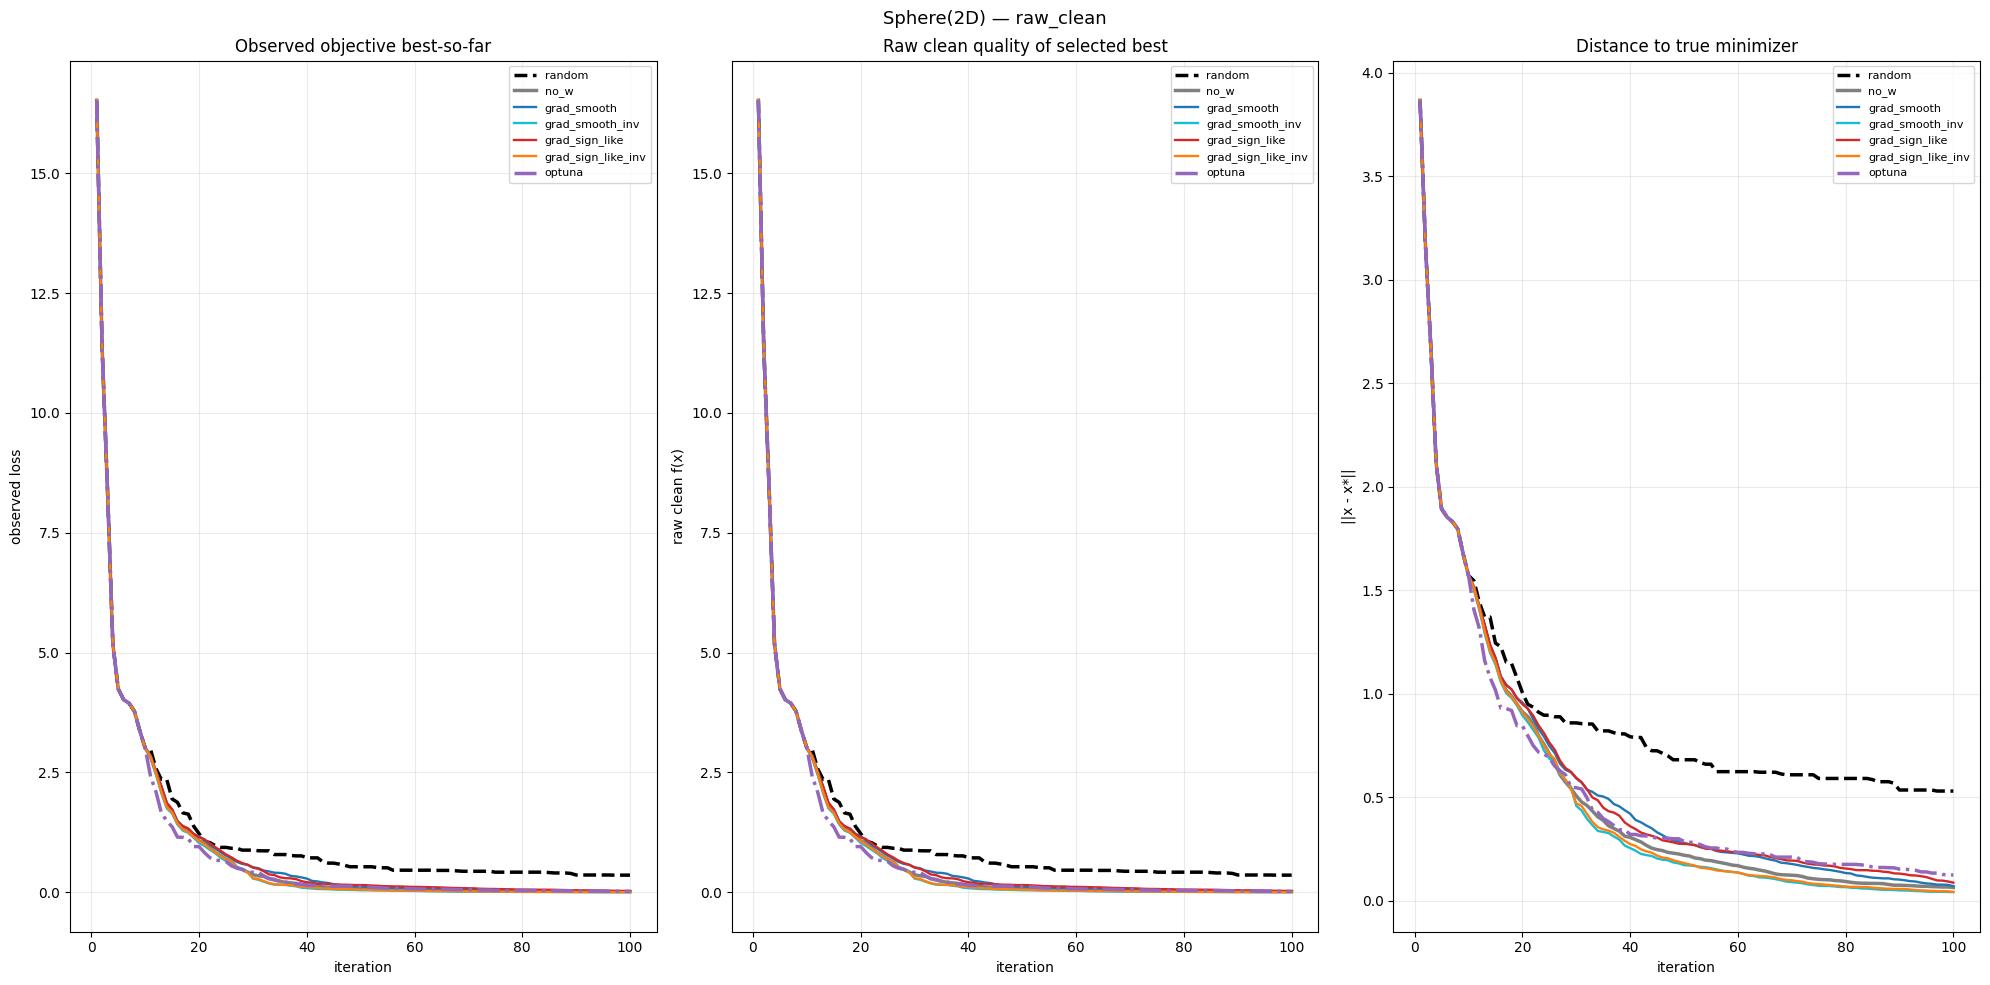

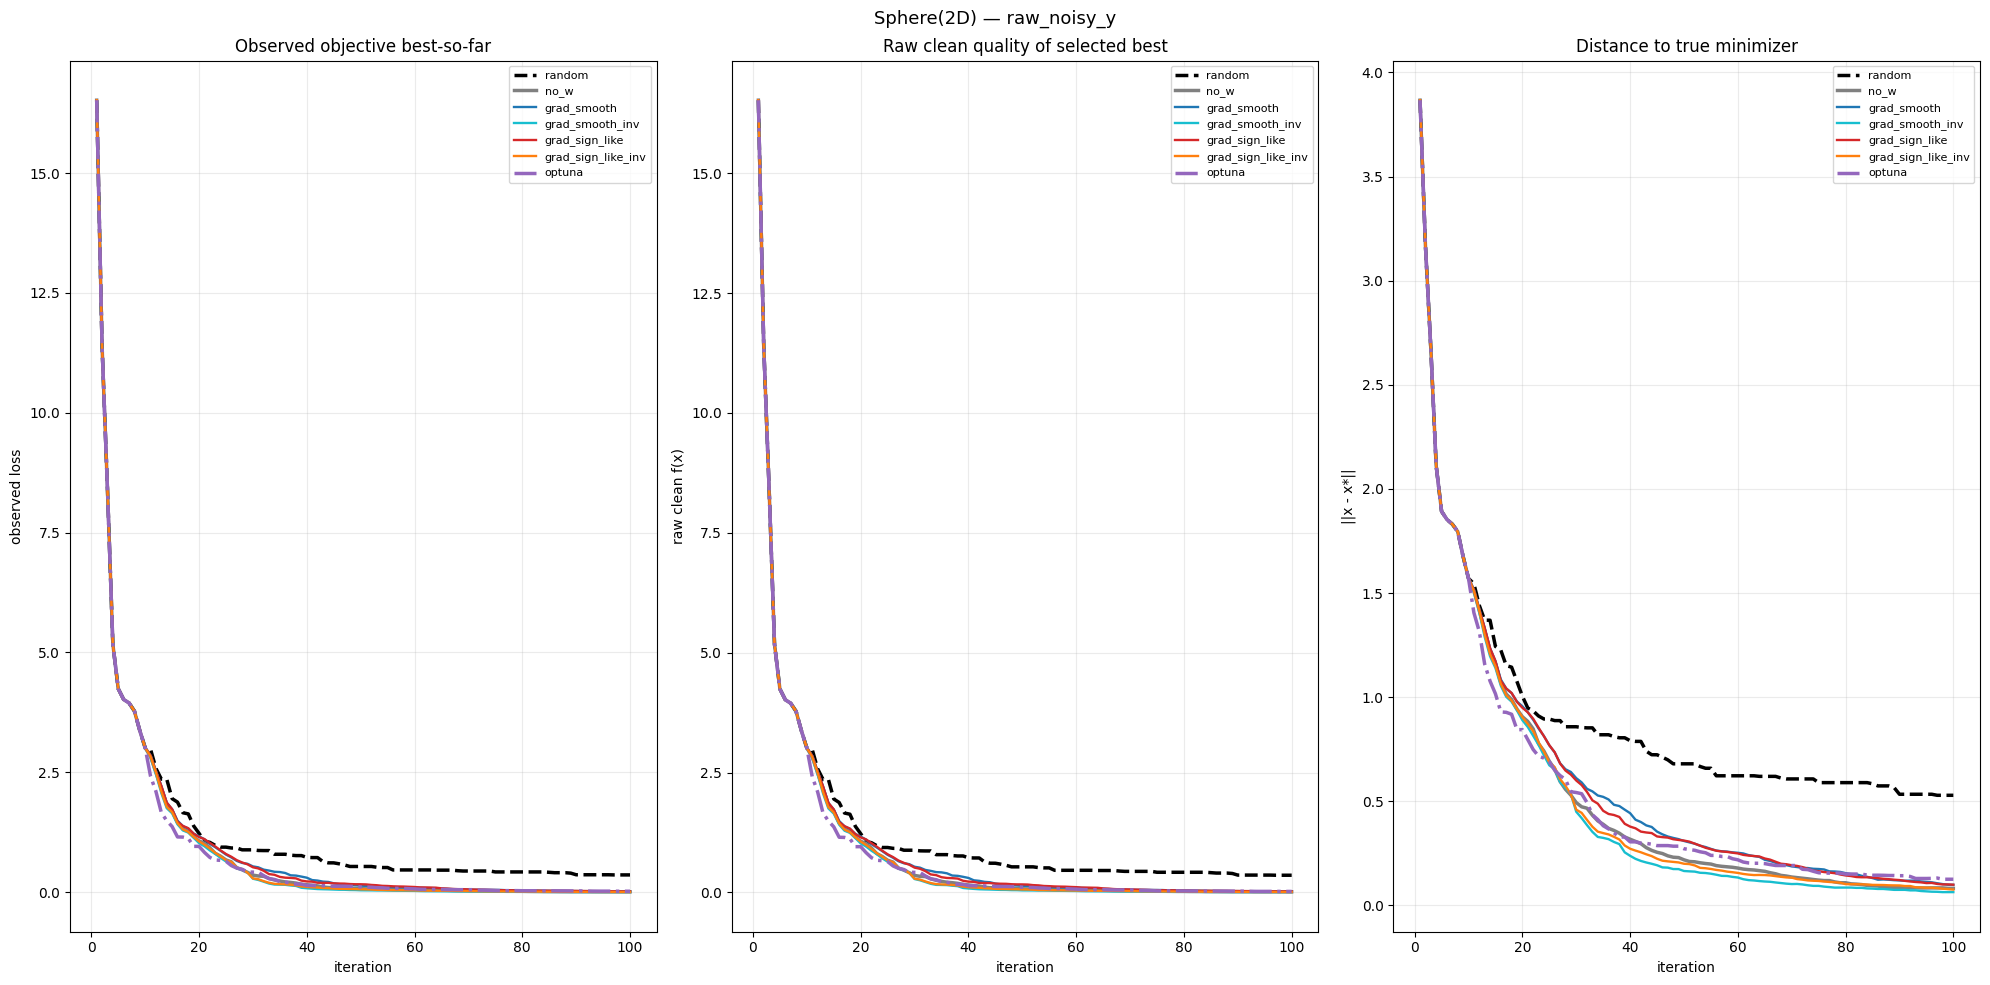

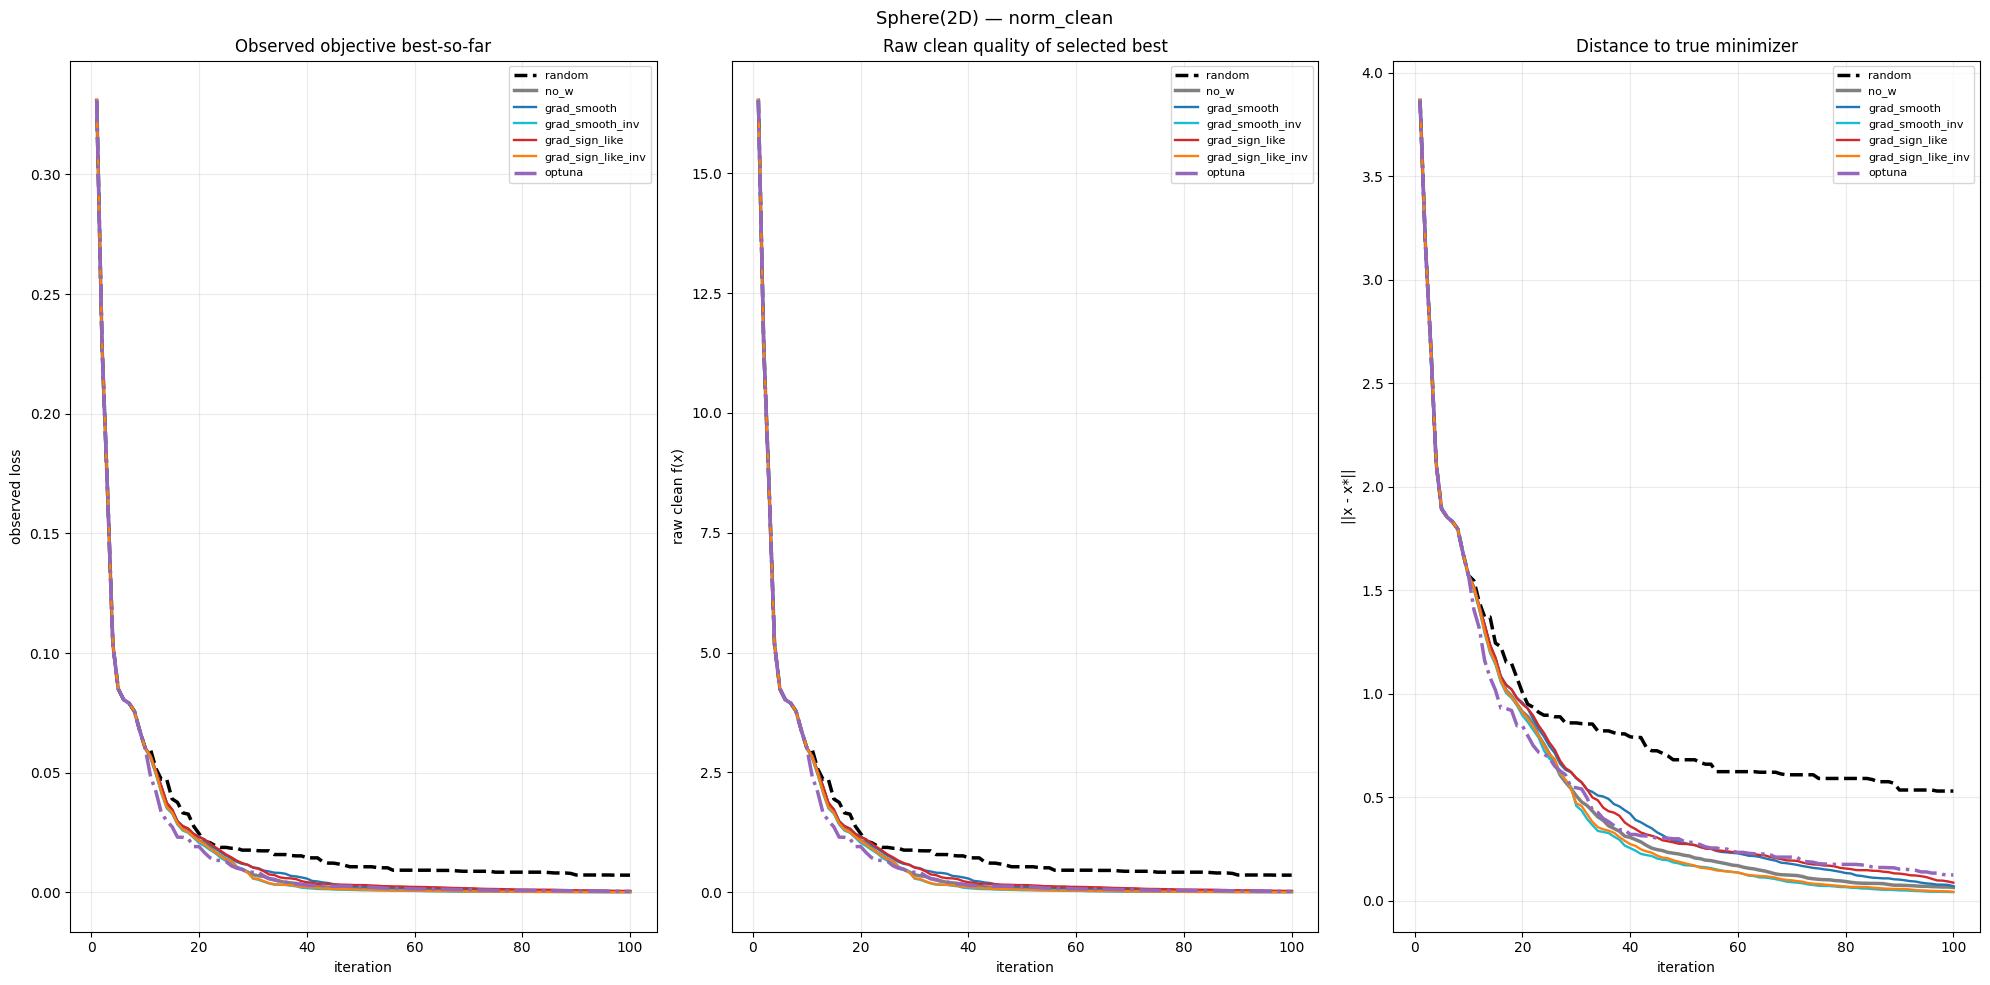

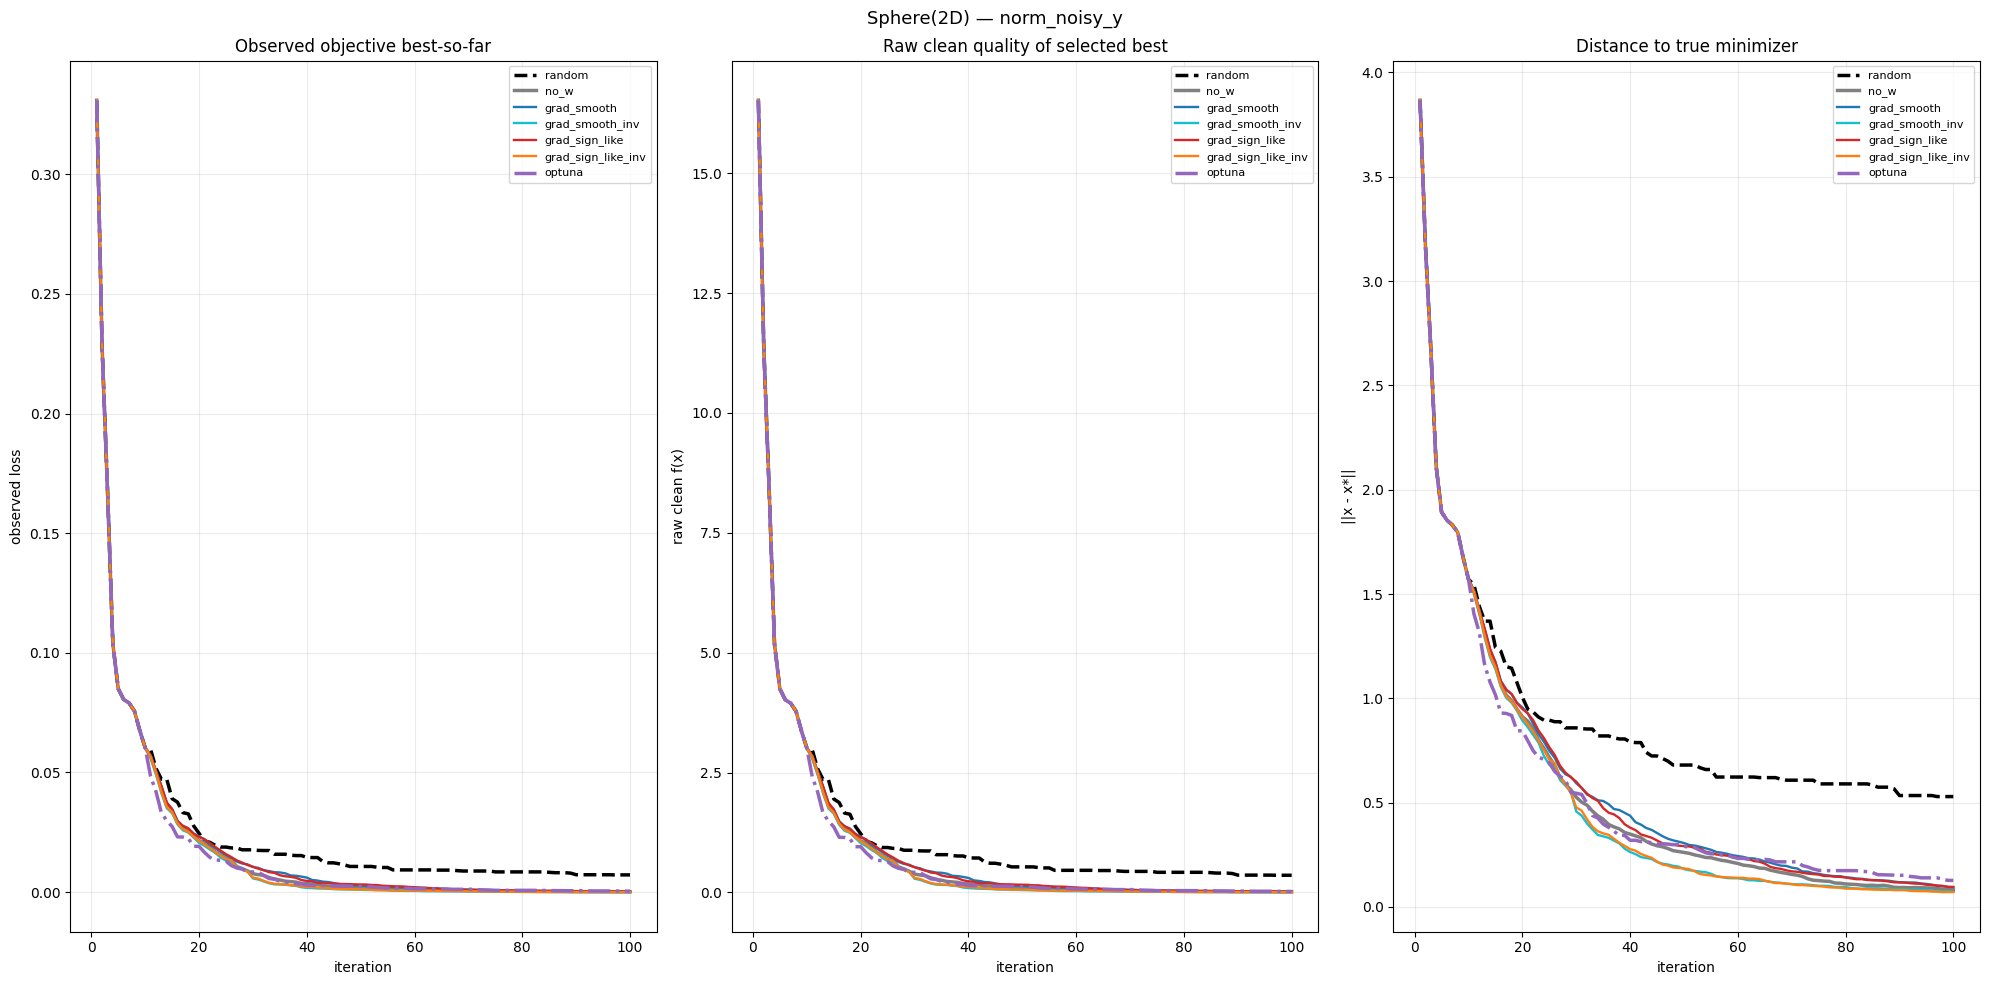

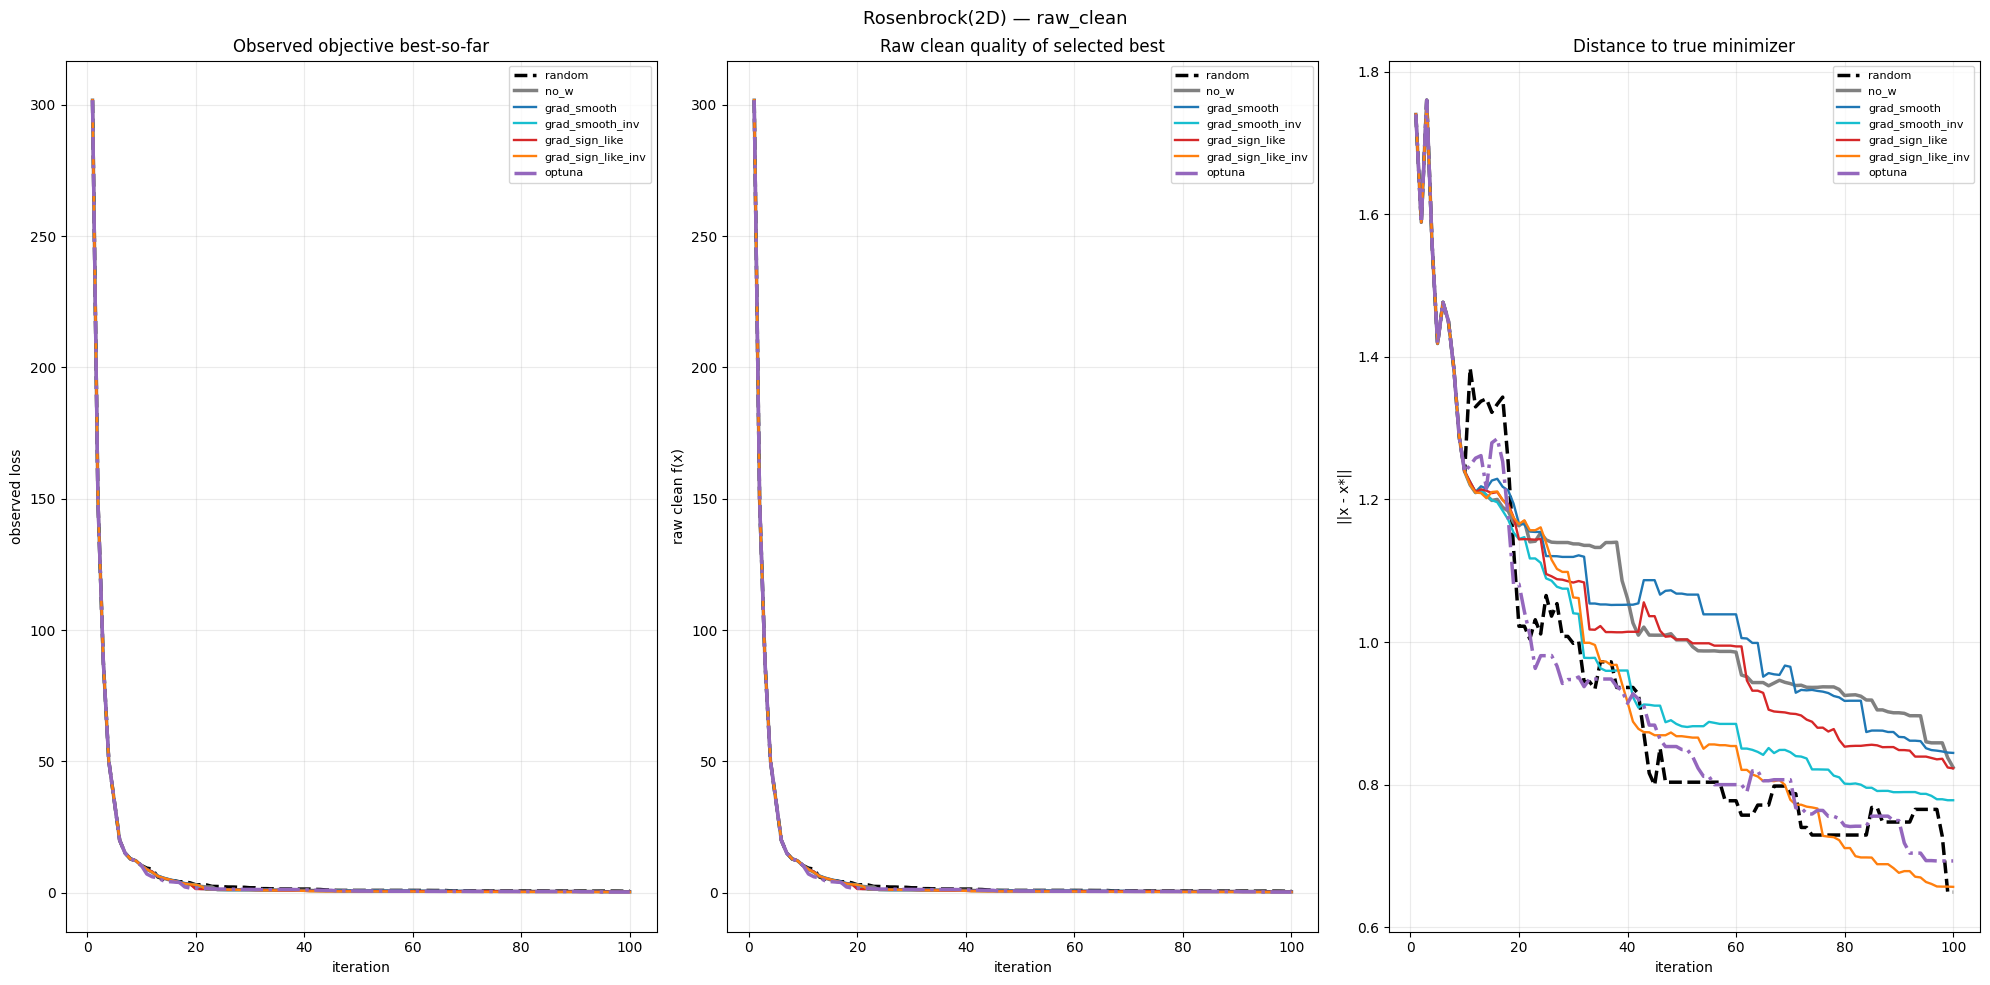

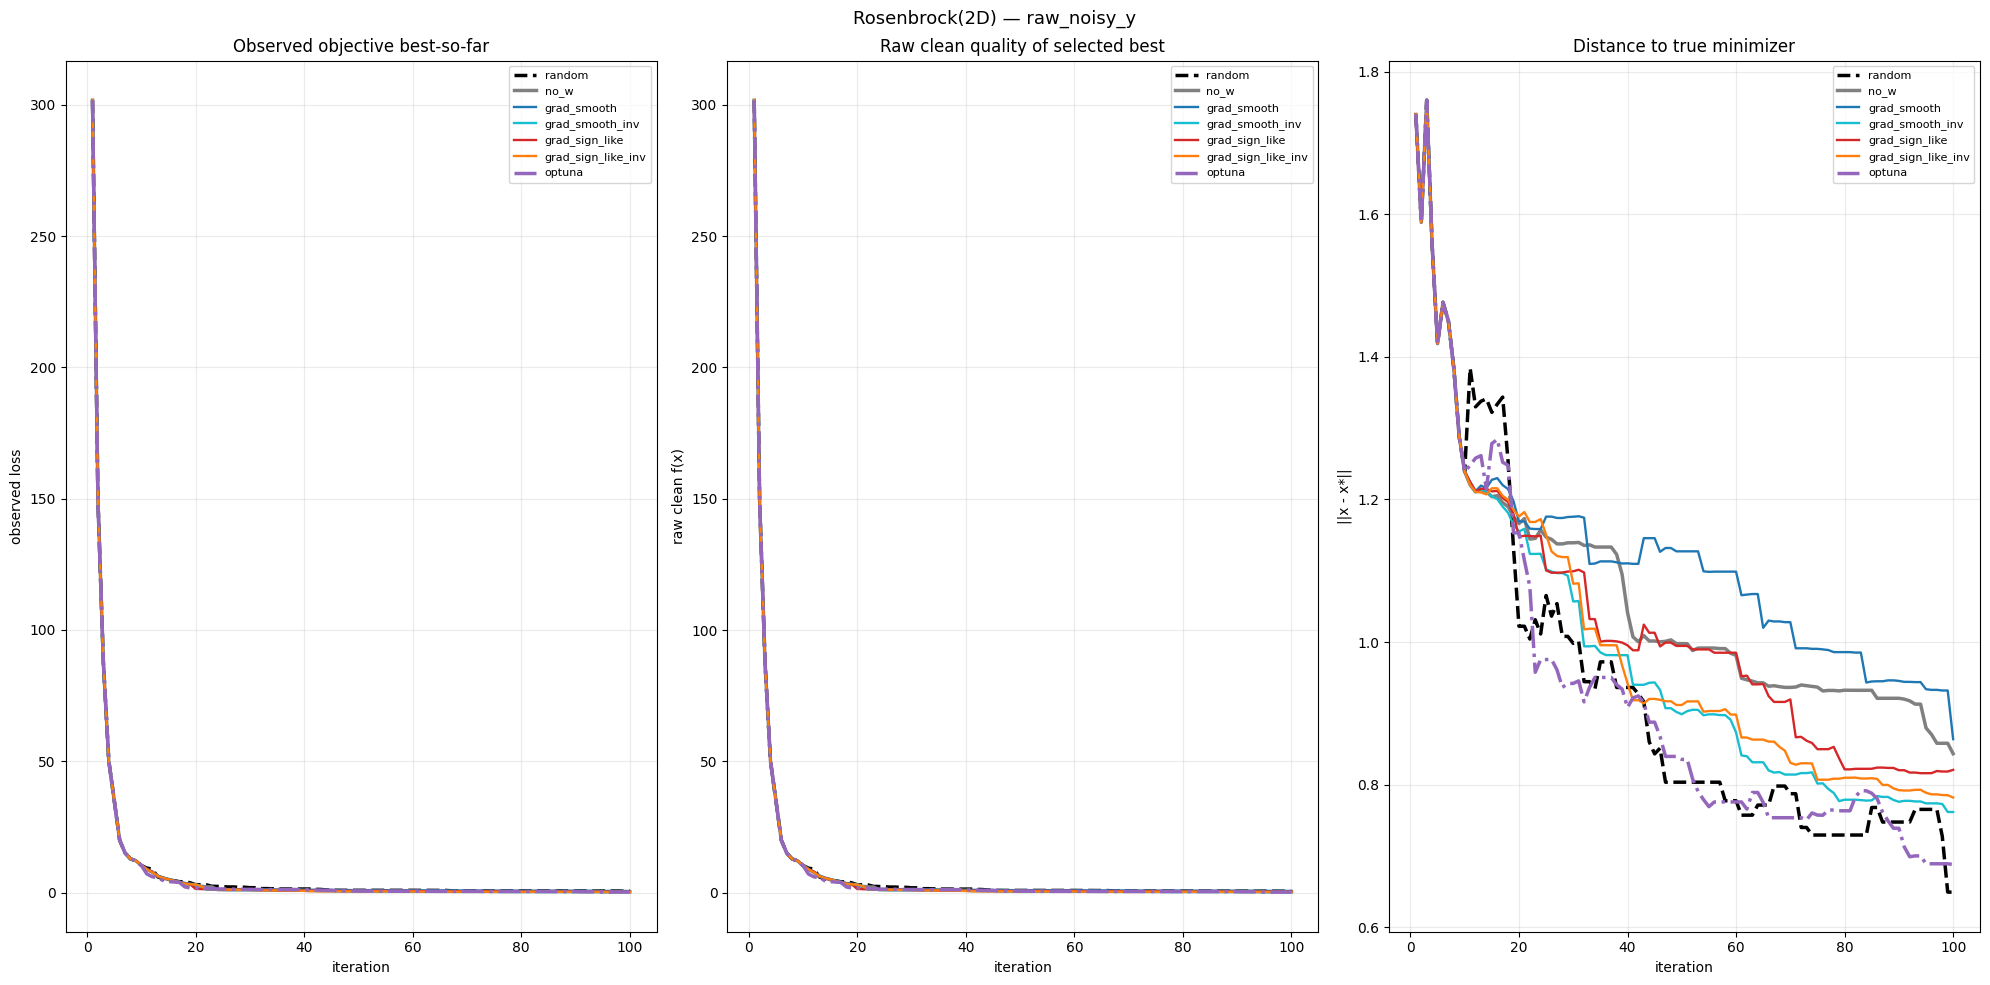

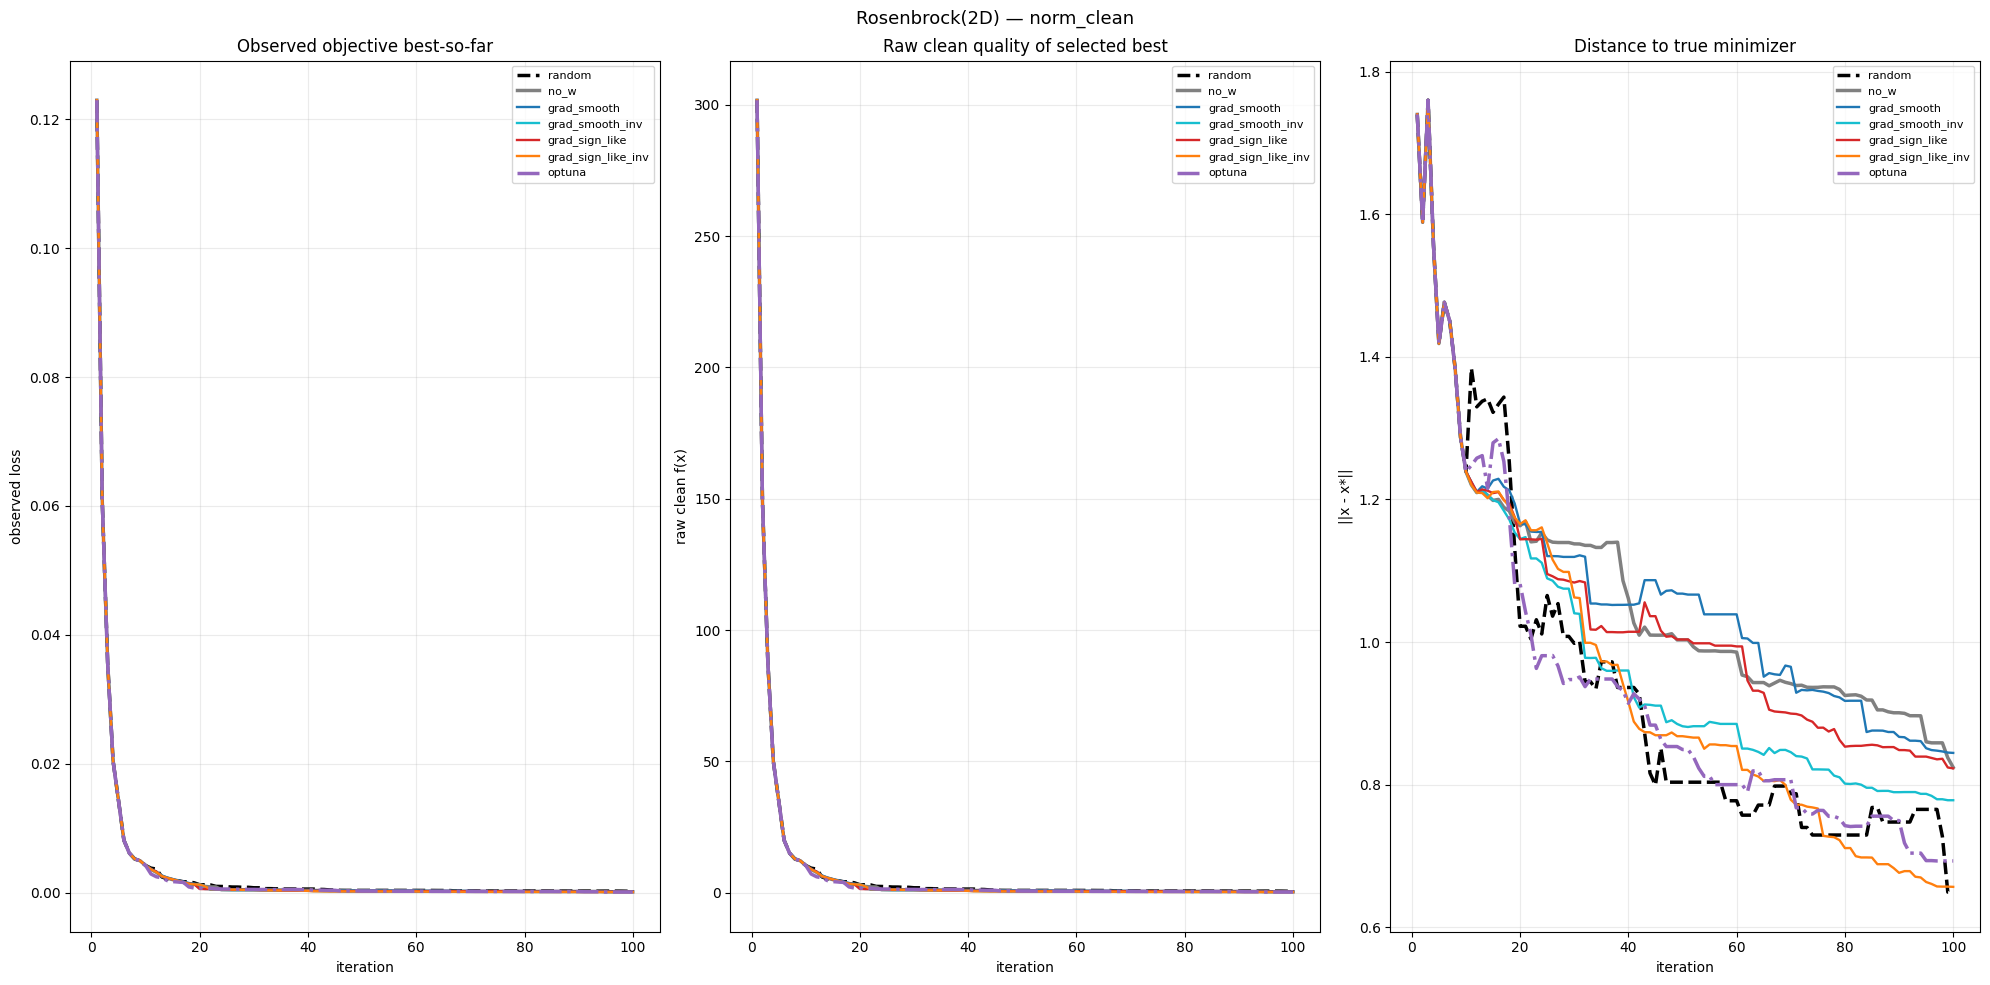

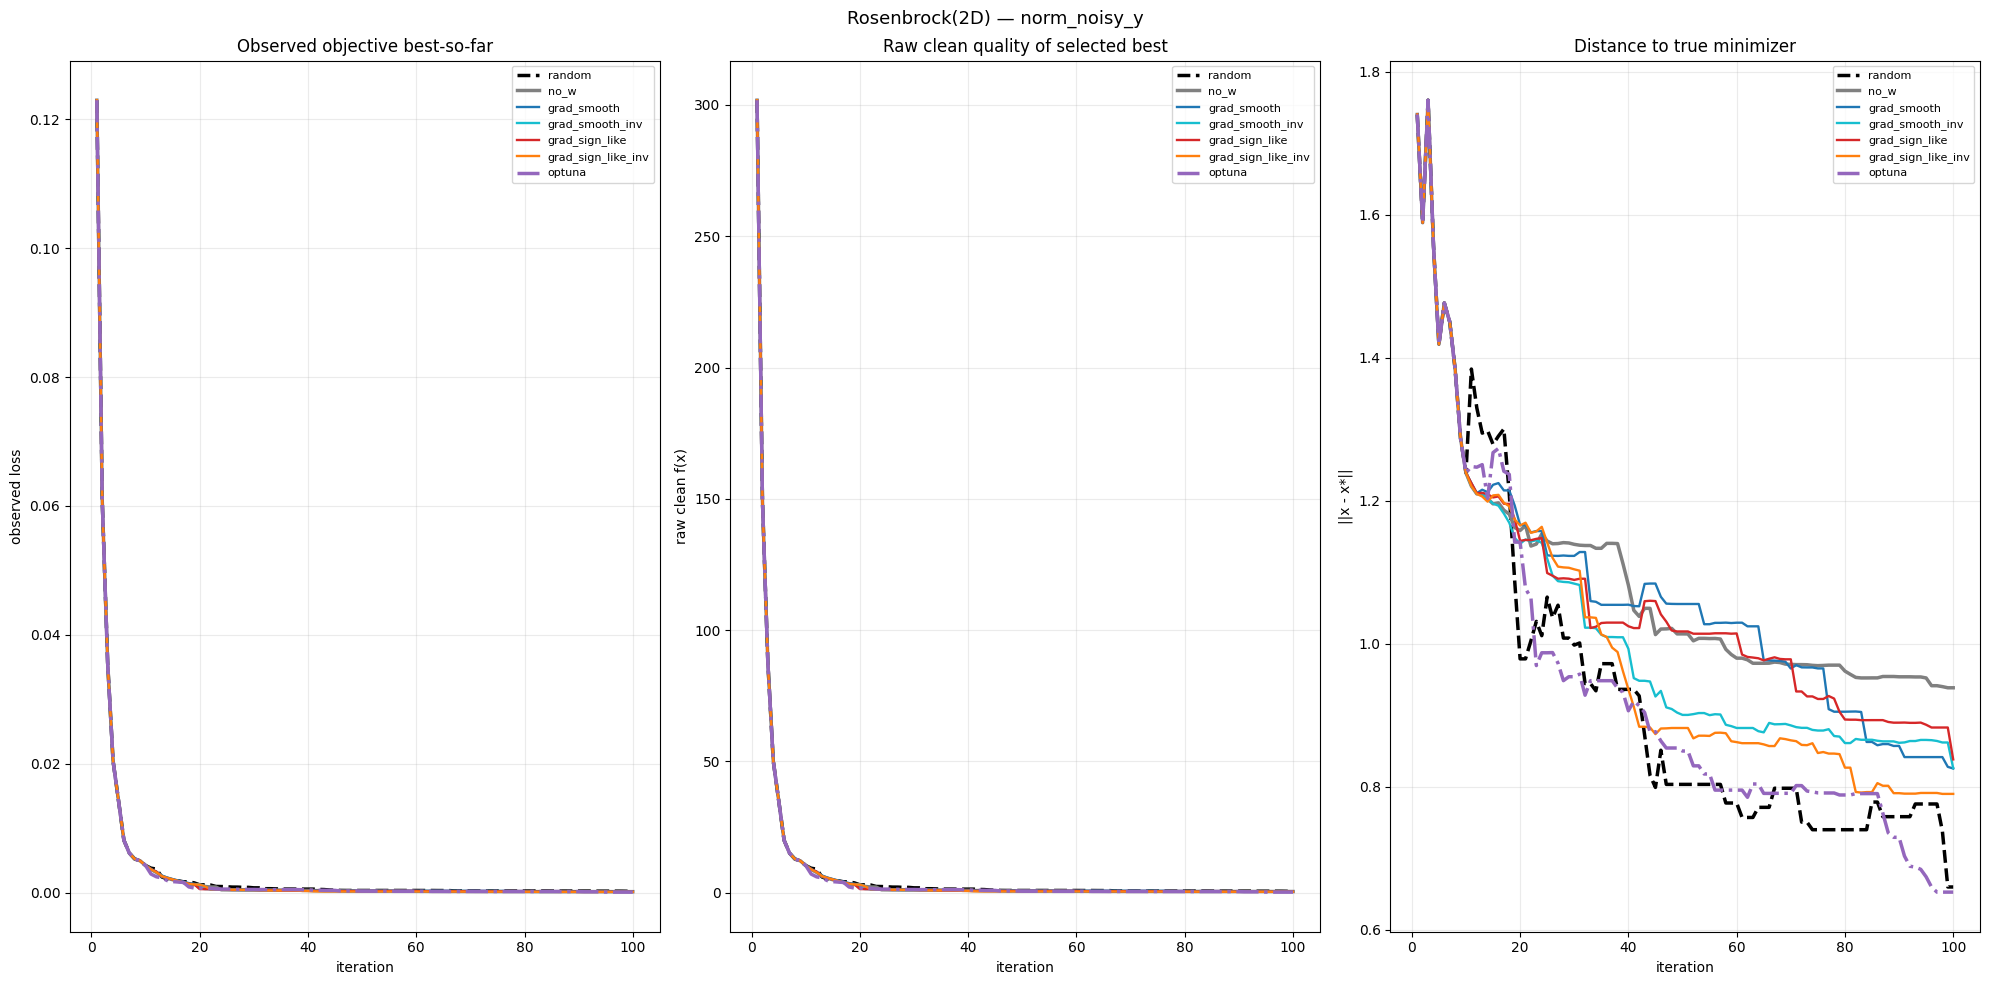

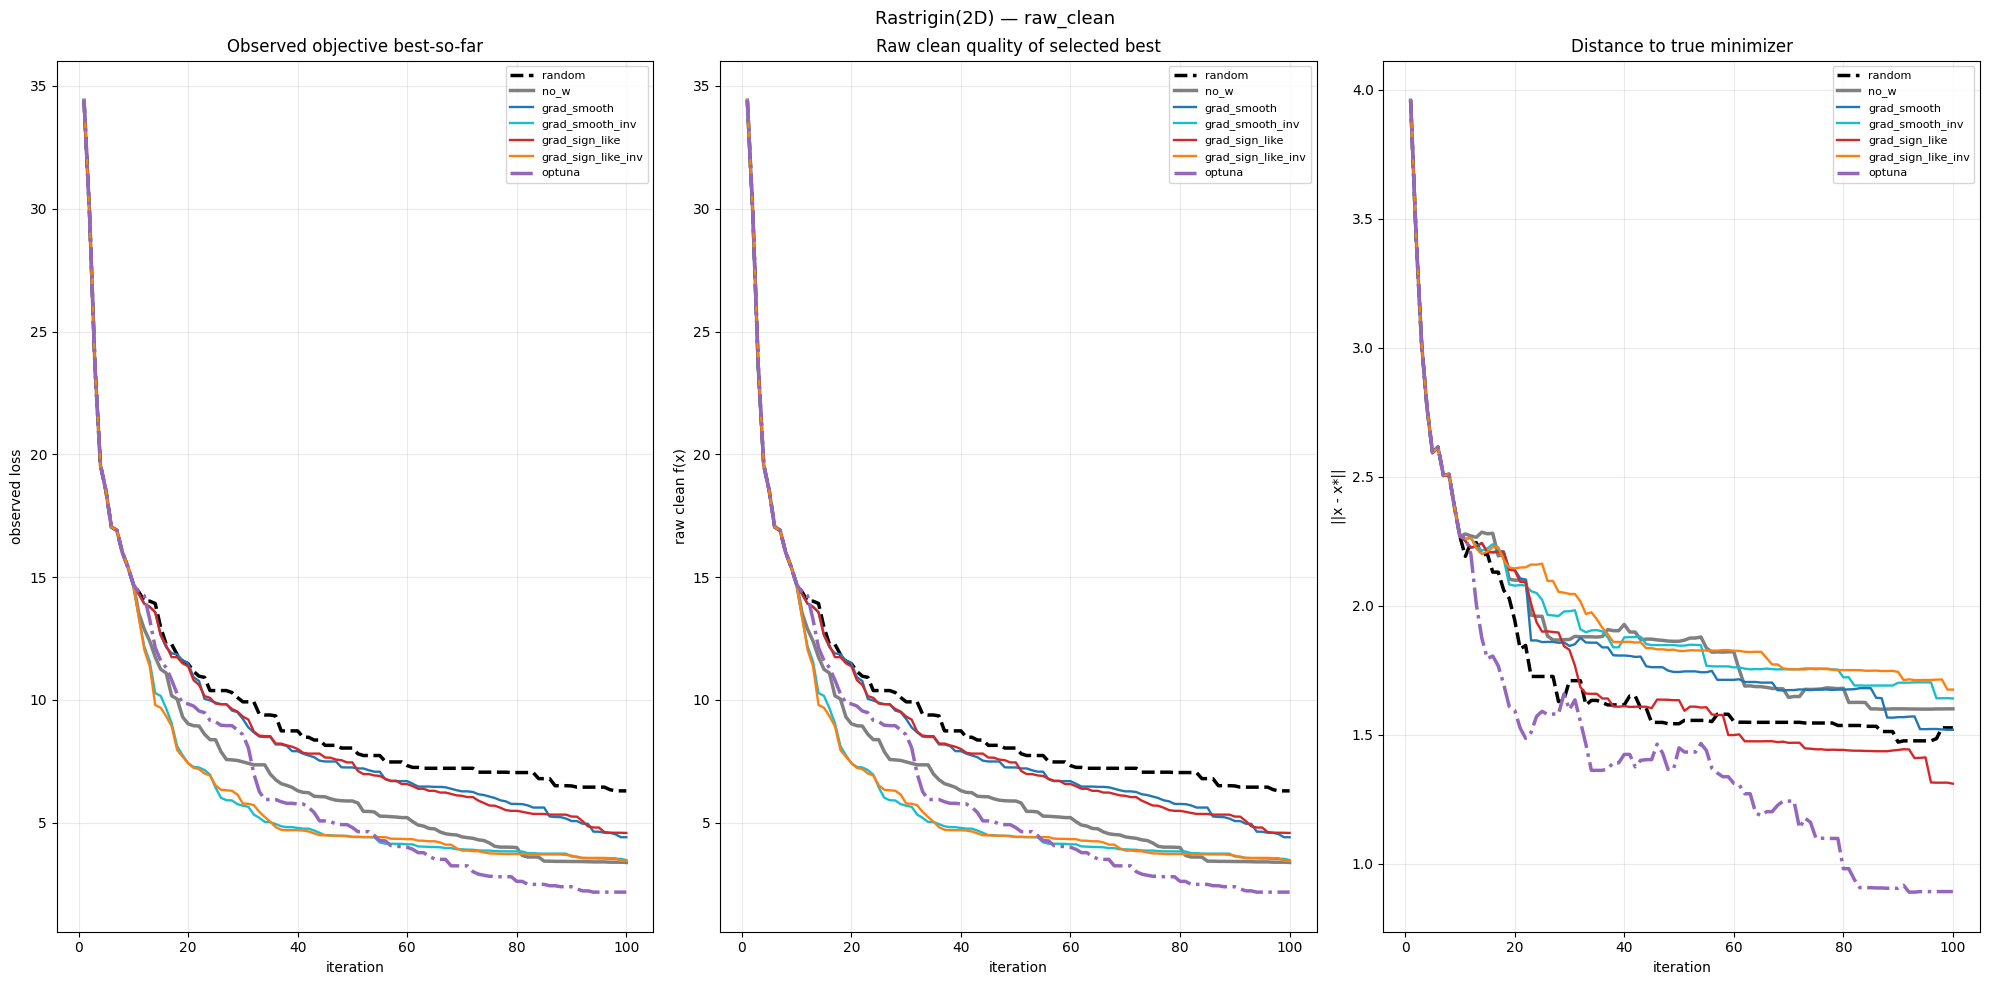

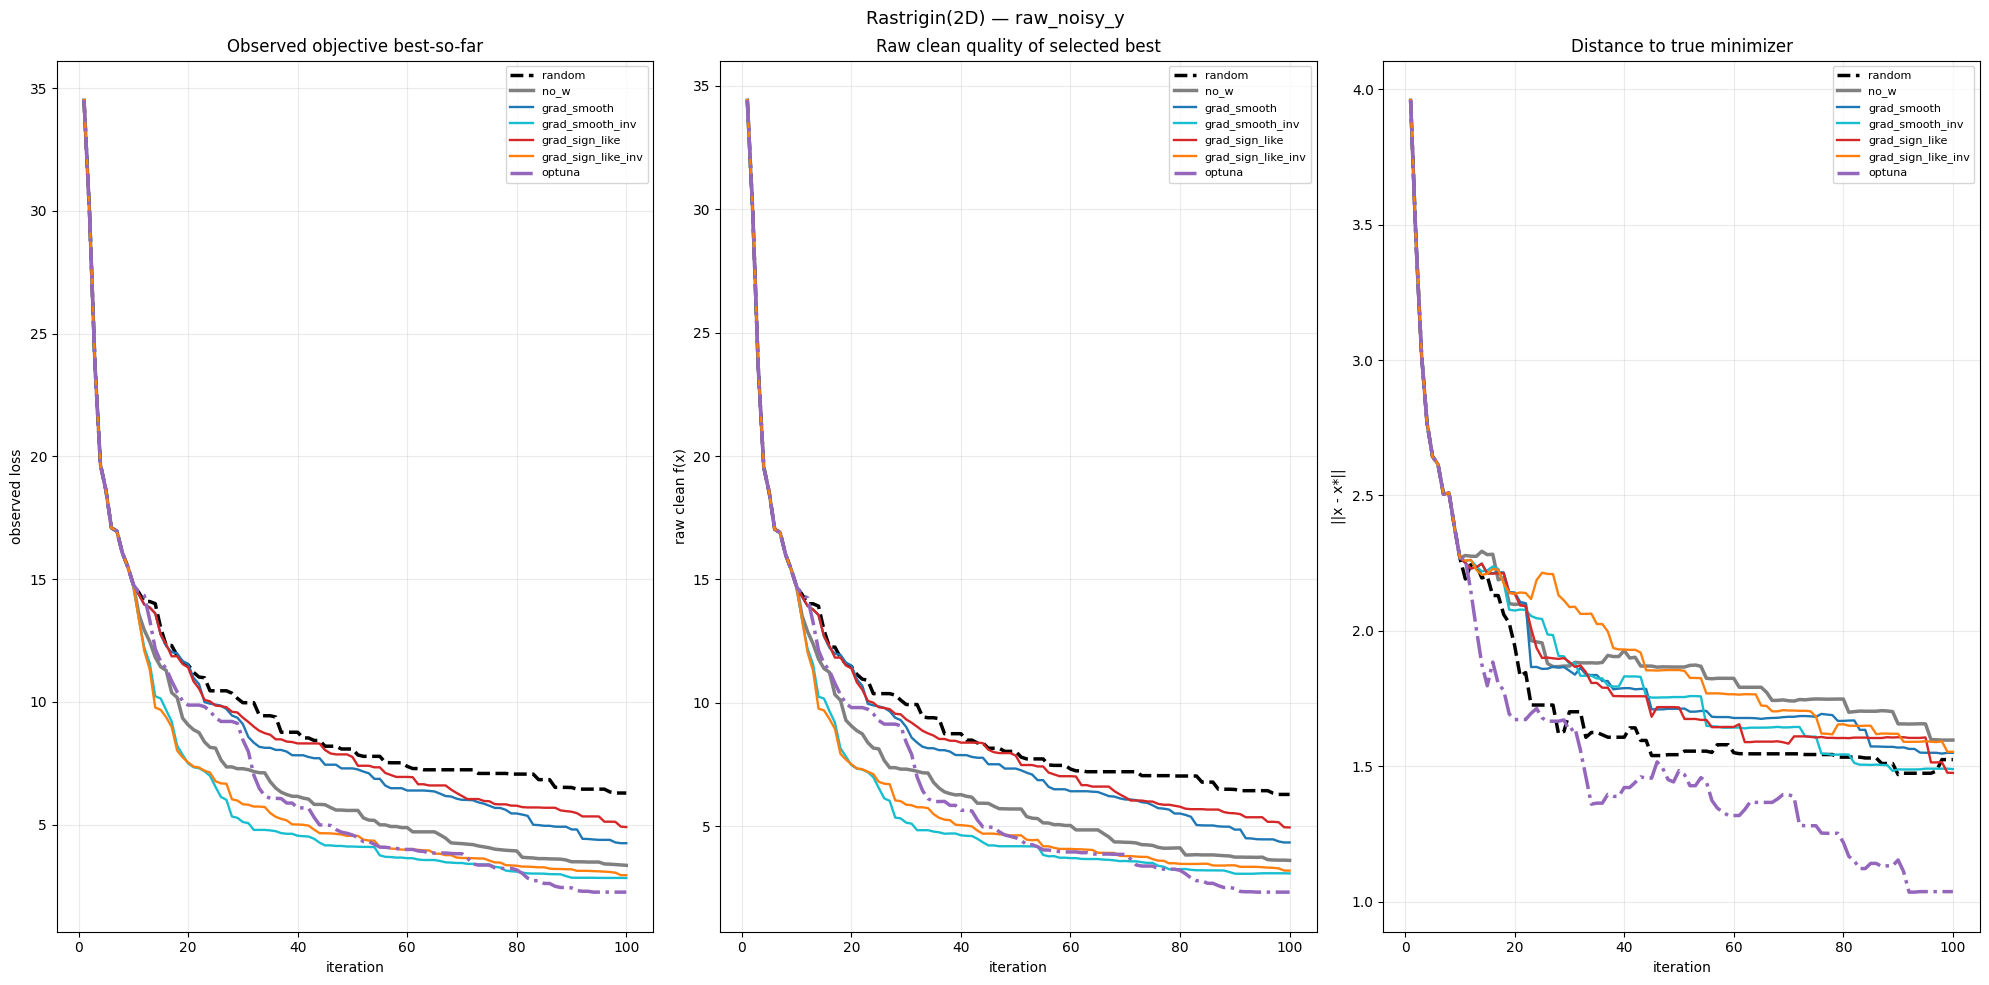

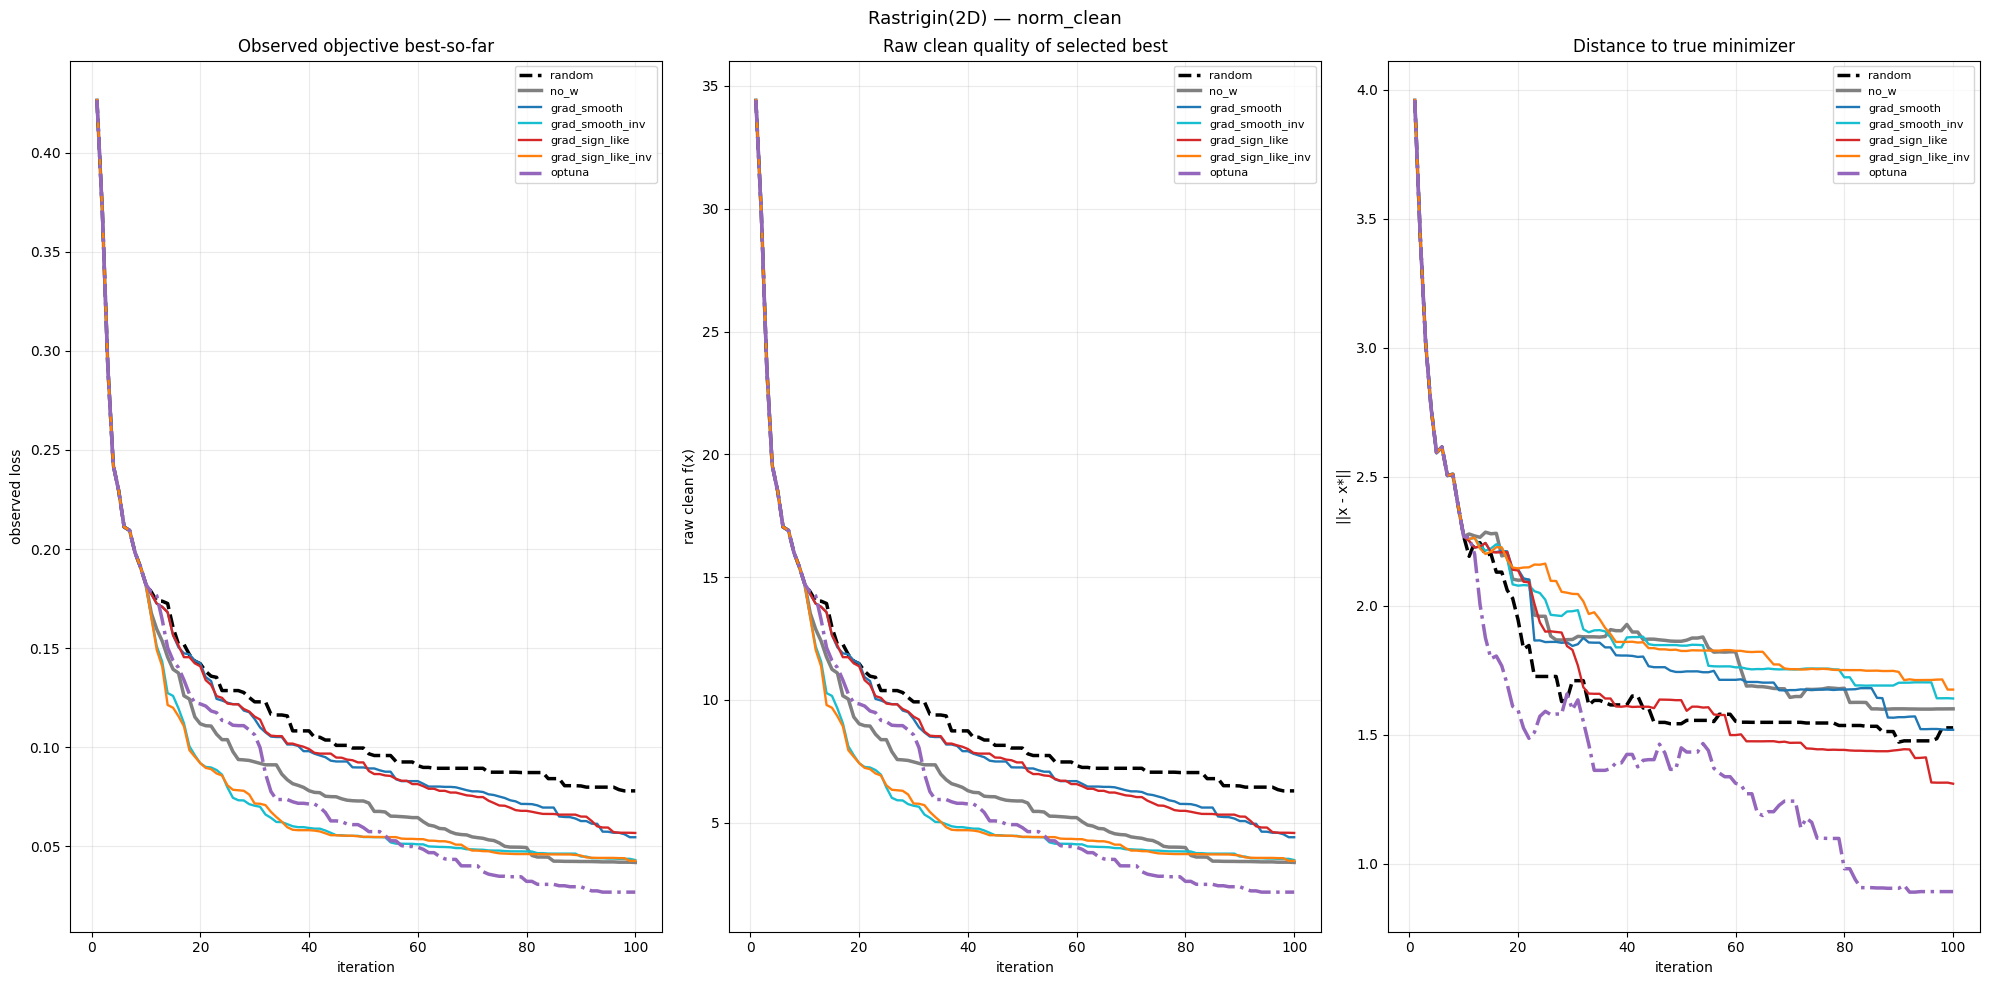

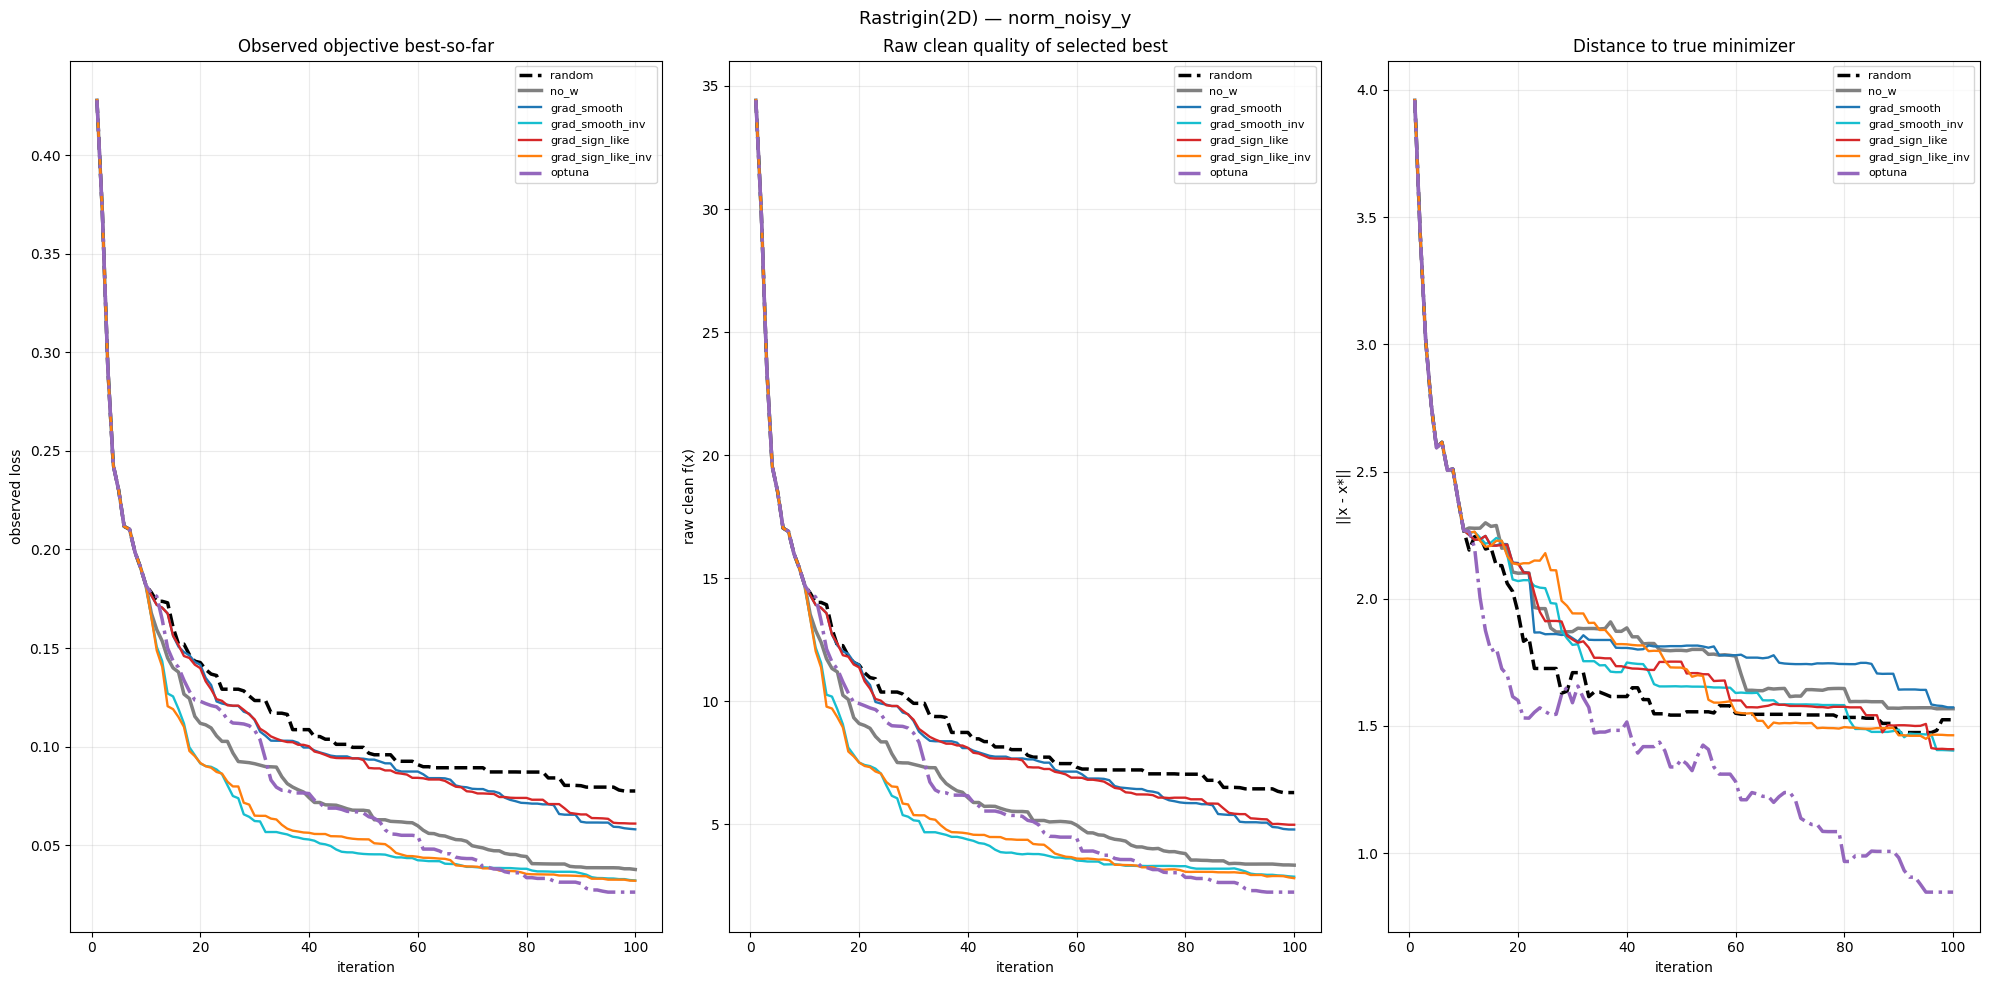

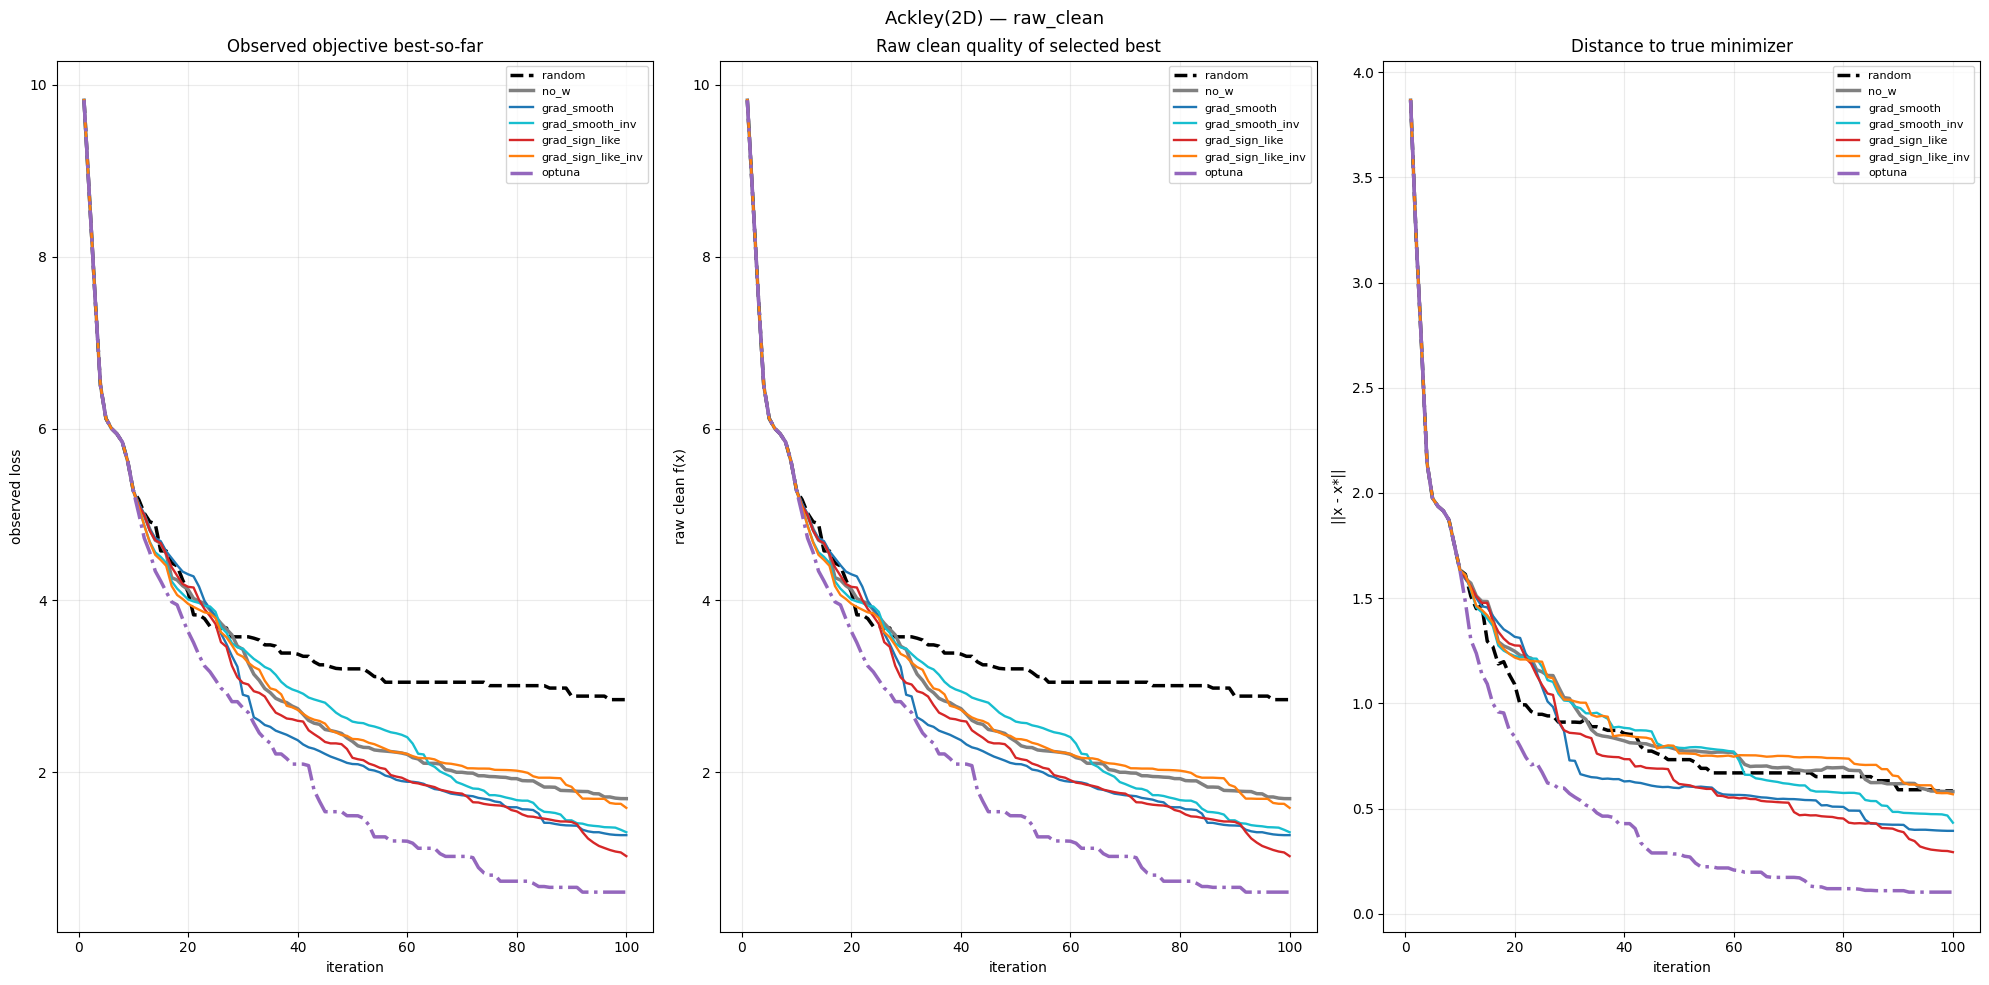

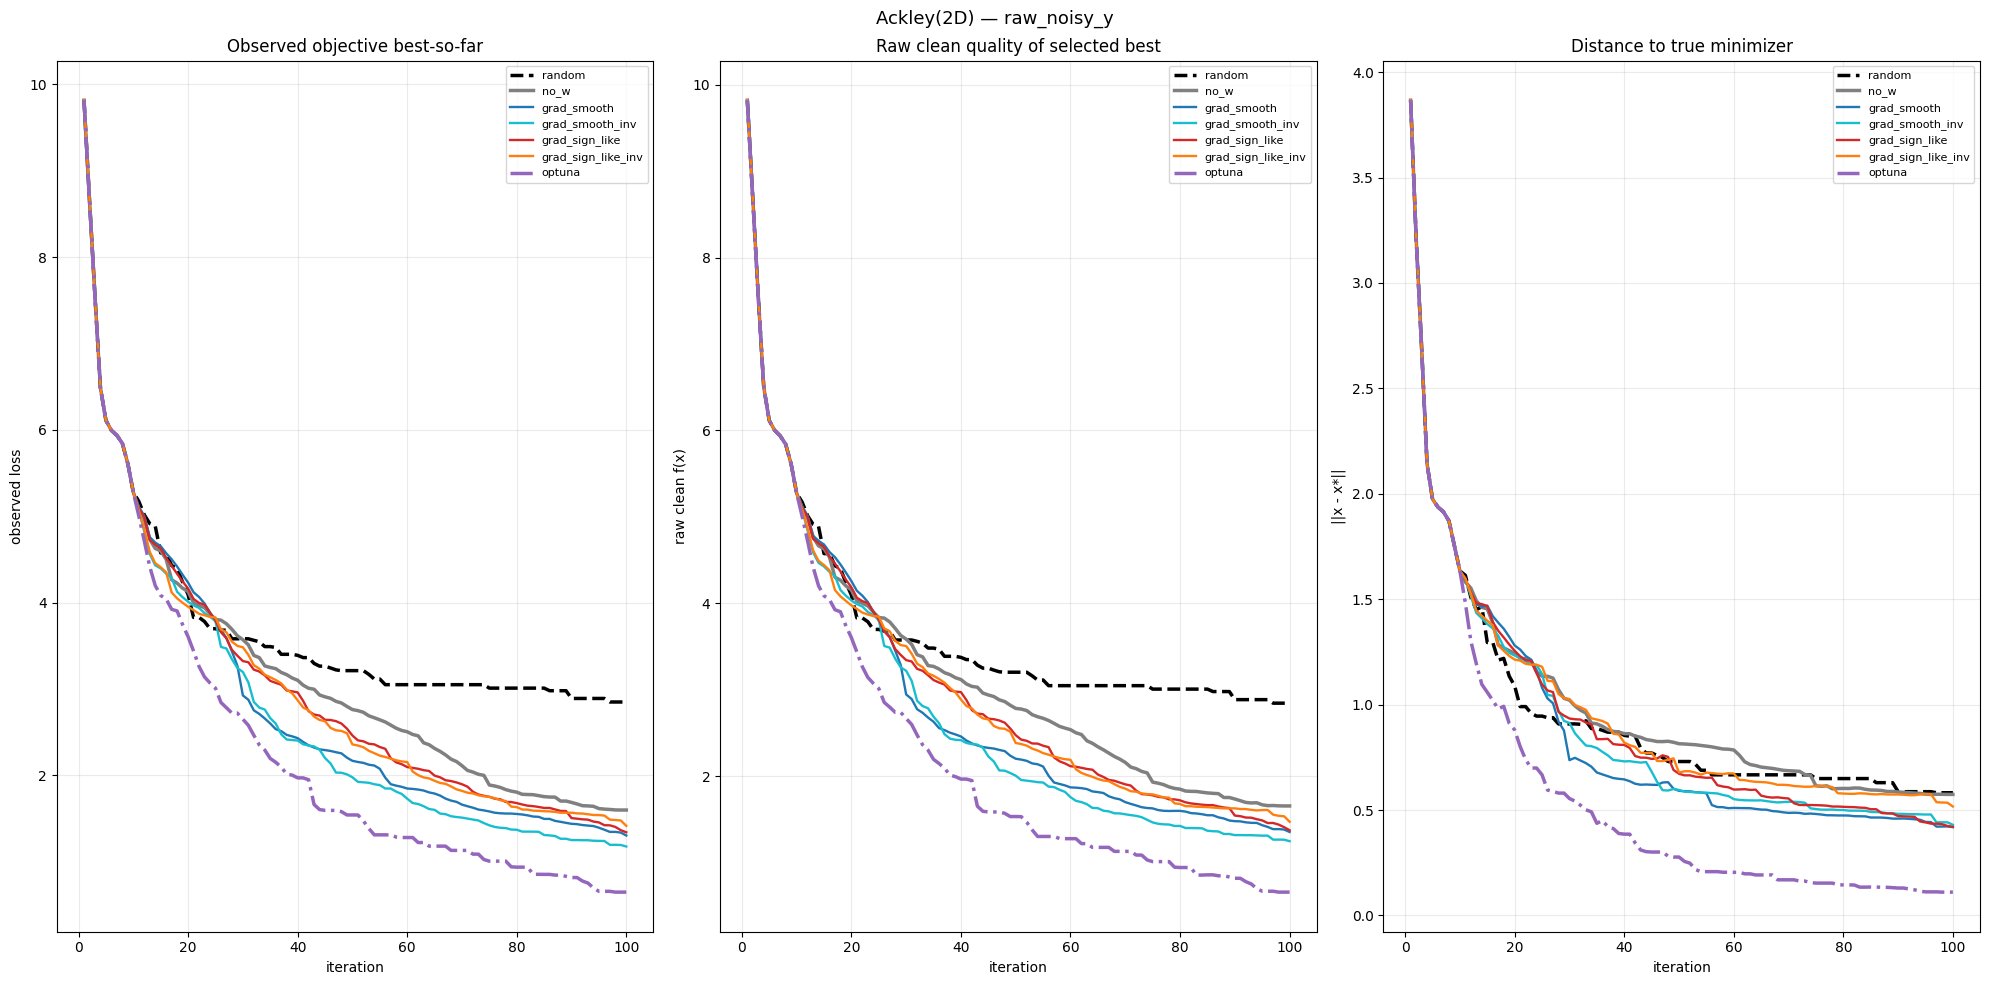

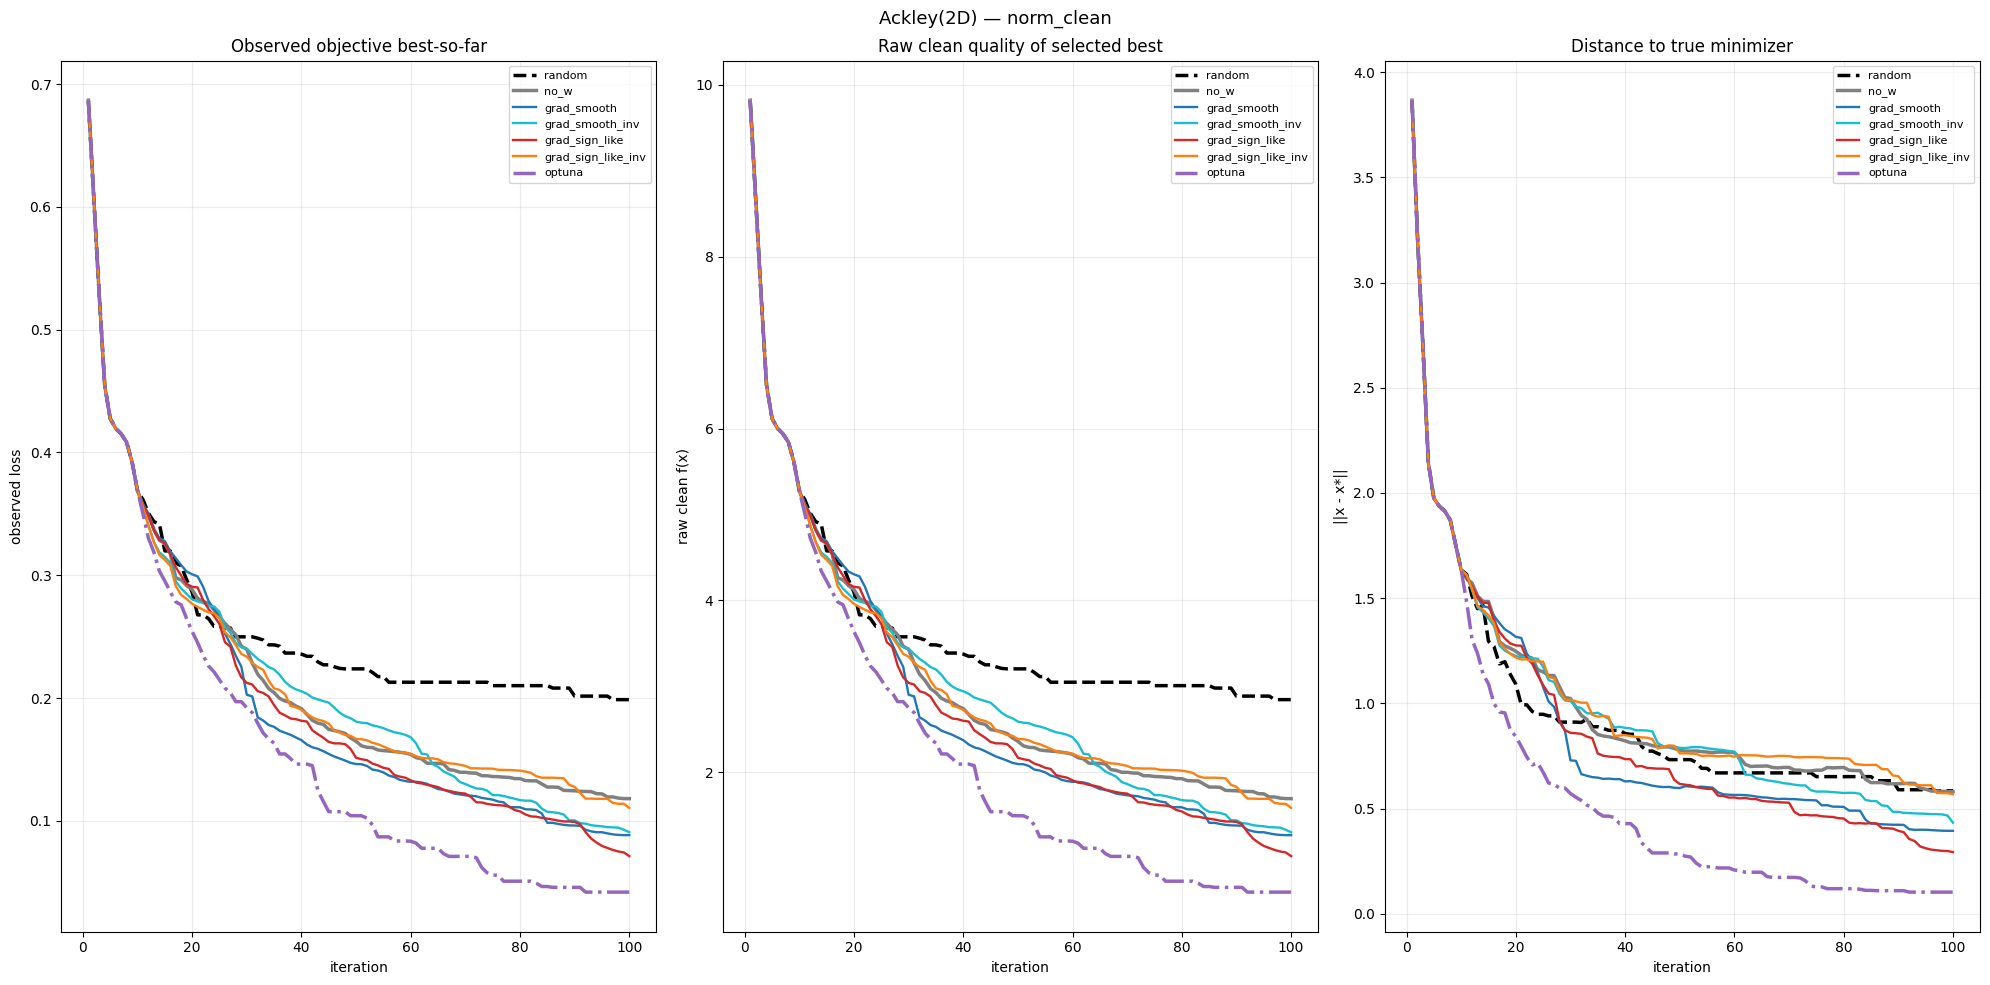

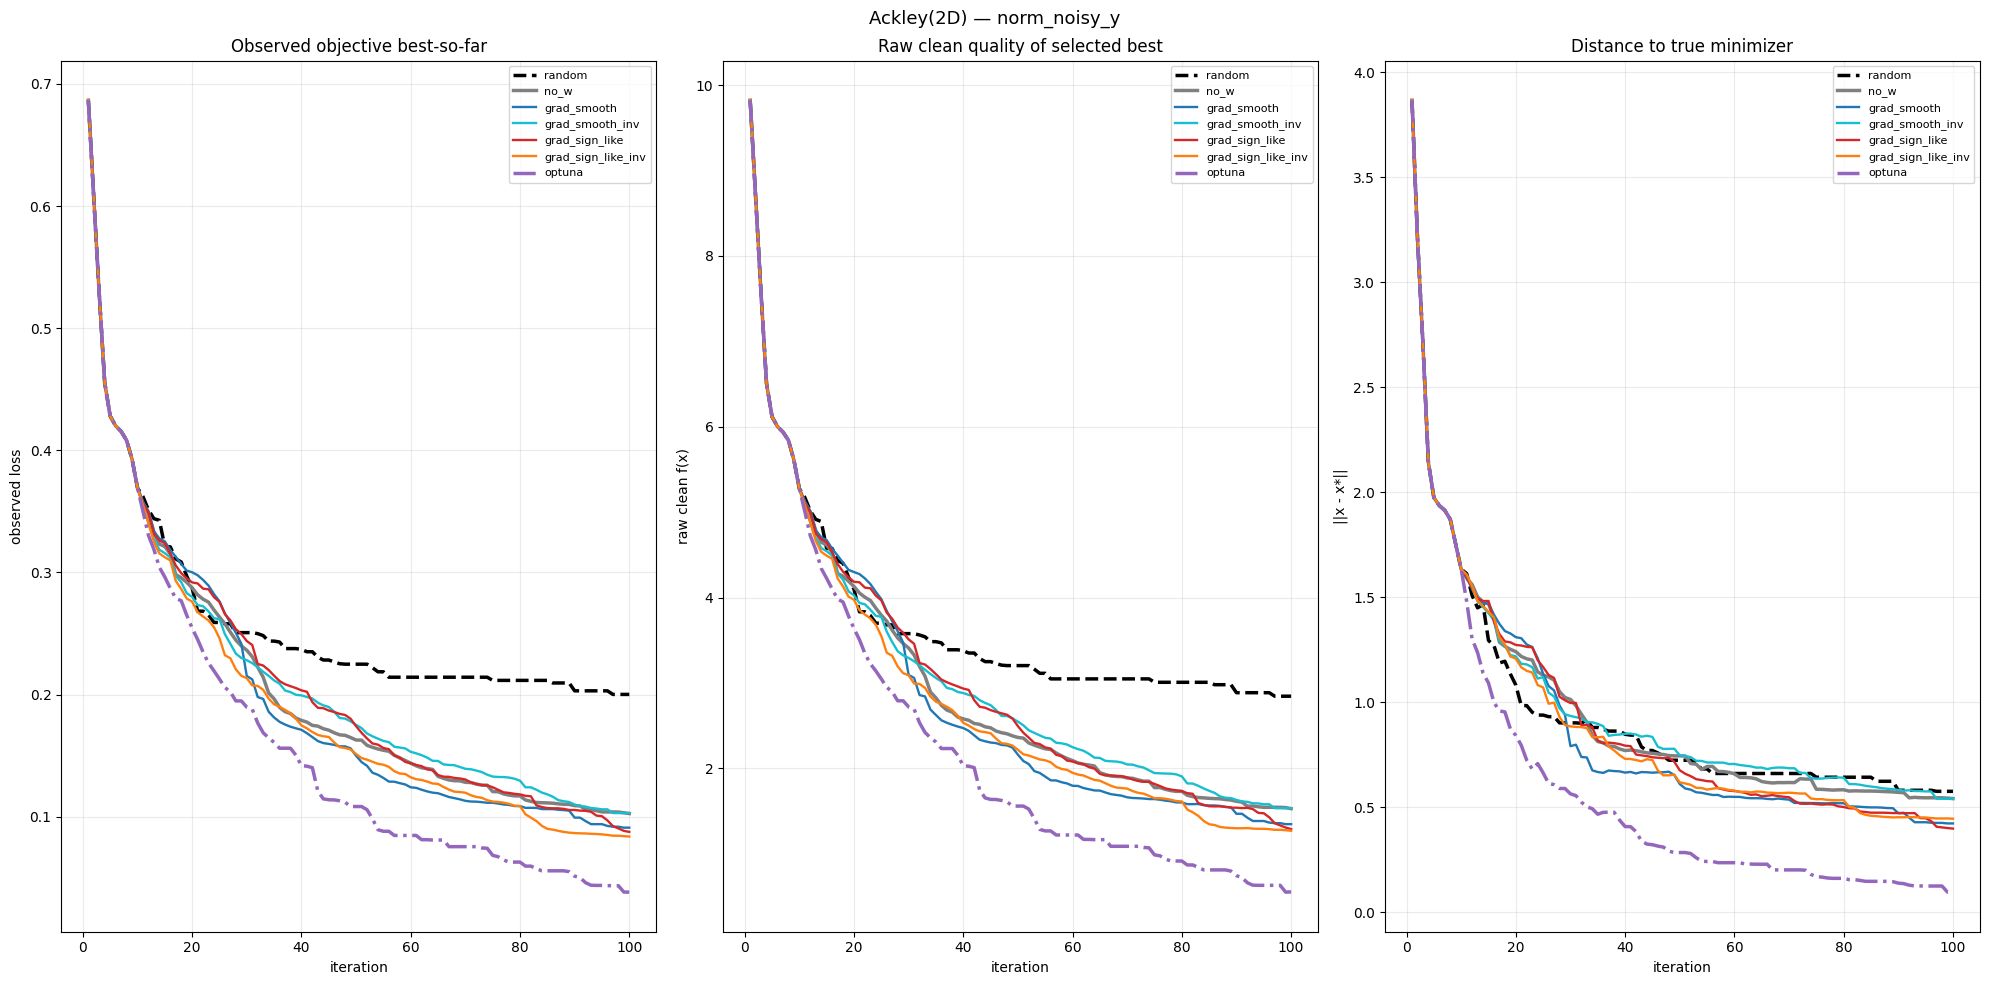

In [ ]:
VARIANT_COLORS = {
    "random": "black",
    "no_w": "gray",
    "grad_smooth": "tab:blue",
    "grad_smooth_inv": "tab:cyan",
    "grad_sign_like": "tab:red",
    "grad_sign_like_inv": "tab:orange",
    "optuna": "tab:purple",
}

VARIANT_STYLES = {
    "random": "--",
    "no_w": "-",
    "grad_smooth": "-",
    "grad_smooth_inv": "-",
    "grad_sign_like": "-",
    "grad_sign_like_inv": "-",
    "optuna": "-.",
}


def _stack_curves(runs, key):
    return np.vstack([np.asarray(r[key], dtype=float) for r in runs])


def plot_variants_for_setting(fn_name, scale_type, data_type):
    results = all_results[fn_name][scale_type][data_type]
    fig, axes = plt.subplots(1, 3, figsize=(20, 10))
    fig.suptitle(f"{fn_name} — {scale_type}_{data_type}", fontsize=13)
    plot_specs = [
        ("best_curve", "Observed objective best-so-far", "observed loss"),
        ("raw_clean_curve", "Raw clean quality of selected best", "raw clean f(x)"),
        ("x_distance_curve", "Distance to true minimizer", "||x - x*||"),
    ]
    for ax, (key, title, ylabel) in zip(axes, plot_specs):
        ax.set_title(title)
        ax.set_xlabel("iteration")
        ax.set_ylabel(ylabel)
        for variant in VARIANT_ORDER:
            runs = results.get(variant, [])
            if len(runs) == 0:
                continue
            curves = _stack_curves(runs, key)
            mean = curves.mean(axis=0)
            std = curves.std(axis=0)
            xs = np.arange(1, len(mean) + 1)
            color = VARIANT_COLORS.get(variant, None)
            linestyle = VARIANT_STYLES.get(variant, "-")
            linewidth = 2.5 if variant in {"random", "no_w", "optuna"} else 1.7
            ax.plot(xs, mean, label=variant, color=color, linestyle=linestyle, linewidth=linewidth)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


for fn_name in RAW_CLEAN_MAP.keys():
    for scale_type in SCALE_TYPES:
        for data_type in DATA_TYPES:
            plot_variants_for_setting(fn_name, scale_type, data_type)

# 14. Point-choice maps

In [ ]:
def _make_contour_grid(fn_name, n_grid=180):
    bounds = BOUNDS_MAP[fn_name]
    x0 = np.linspace(bounds[0][0], bounds[0][1], n_grid)
    x1 = np.linspace(bounds[1][0], bounds[1][1], n_grid)
    X0, X1 = np.meshgrid(x0, x1)
    Z = np.zeros_like(X0, dtype=float)
    raw_fn = RAW_CLEAN_MAP[fn_name]
    for i in range(n_grid):
        for j in range(n_grid):
            Z[i, j] = raw_fn(np.array([X0[i, j], X1[i, j]], dtype=float))
    return X0, X1, Z


def plot_choice_map(fn_name, scale_type, data_type, variant, seed_index=0, n_grid=160):
    runs = all_results[fn_name][scale_type][data_type].get(variant, [])
    if len(runs) == 0:
        print(f"No runs for {fn_name} / {scale_type}_{data_type} / {variant}")
        return
    run = runs[seed_index]
    xs = np.asarray(run["x_history"], dtype=float)
    X0, X1, Z = _make_contour_grid(fn_name, n_grid=n_grid)
    plt.figure(figsize=(7, 6))
    plt.contourf(X0, X1, Z, levels=40, alpha=0.75)
    plt.colorbar(label="raw clean f(x)")
    plt.plot(xs[:, 0], xs[:, 1], marker="o", markersize=3, linewidth=1.0, label="chosen points")
    plt.scatter(xs[0, 0], xs[0, 1], s=80, marker="s", label="first")
    plt.scatter(xs[-1, 0], xs[-1, 1], s=90, marker="*", label="last")
    plt.scatter(TRUE_MINIMA[fn_name][0], TRUE_MINIMA[fn_name][1], s=90, marker="x", label="true minimum")
    plt.title(f"{fn_name}: {variant}, {scale_type}_{data_type}, seed={run['seed']}")
    plt.xlabel("x0")
    plt.ylabel("x1")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# Пример:
# plot_choice_map("Ackley(2D)", "norm", "noisy_y", "no_w", seed_index=0)
# plot_choice_map("Ackley(2D)", "norm", "noisy_y", "grad_smooth", seed_index=0)

# 15. Interpretation guide

Для статьи интерпретировать результаты лучше в таком порядке:

1. Сначала сравнить `no_w` с `random` и `optuna`, чтобы показать, что базовый TPE ведет себя осмысленно.
2. Затем сравнить `grad_*` только с `no_w` внутри одной и той же пары `scale_type` / `data_type`.
3. Основные метрики брать из `summary_visible_df`: `success_rate_%`, `steps_mean`, `final_dist_x_mean`, `final_dist_y_mean`.
4. Если noisy-режим дает противоречивый результат, смотреть не только среднее, но и дисперсию/медиану.
5. Для строгой корректности нужно отдельно проверить, как именно в вашем `TPEOptimizer` вызывается `weight_fn`: по полным 2D-точкам или покоординатно. Если покоординатно, текущая gradient-weight логика является эвристикой, а не полноценным учетом \(\nabla f(x_0, x_1)\).